# Experiment Analysis — Span Classification for Decoder-Only Transformer Models


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import seaborn as sns
import warnings
import os
from pathlib import Path
from matplotlib.gridspec import GridSpec
from IPython.display import Image, display

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
})
sns.set_style('whitegrid')

BASE = Path('/mnt/c/Users/radek/master_thesis/Experiment_results')
PLOTS = BASE / 'Plots'
PLOTS.mkdir(exist_ok=True)

MODEL_COLORS = {
    'Gemma-3 4B':   '#4C72B0',
    'Qwen3 8B':     '#DD8452',
    'GPT-OSS 20B':  '#55A868',
    'Llama-3.1 8B': '#C44E52',
}
PROC_COLORS = {
    'Unconstrained':  '#E15759',
    'Whole-Sequence': '#4E79A7',
    'Token-Aware':    '#F28E2B',
}
PROMPT_COLORS = {
    'Base':     '#4C72B0',
    'Markdown': '#DD8452',
    'Short':    '#55A868',
}
print("Setup complete. Plots directory:", PLOTS)


Setup complete. Plots directory: /mnt/c/Users/radek/master_thesis/Experiment_results/Plots


In [2]:
MODEL_MAP = {
    'google/gemma-3-4b-it': 'Gemma-3 4B', 'gemma3:4b': 'Gemma-3 4B',
    'Qwen/Qwen3-8B': 'Qwen3 8B', 'qwen3:8b': 'Qwen3 8B',
    'meta-llama/Llama-3.1-8B-Instruct': 'Llama-3.1 8B', 'llama3.1:8b': 'Llama-3.1 8B',
    'gpt-oss:20b': 'GPT-OSS 20B',
}
PROMPT_MAP = {
    'SYSTEM_PROMPT_CONTEXT': 'Base', 'SYSTEM_PROMPT_CONTEXT_MD': 'Markdown',
    'SYSTEM_PROMPT_CONTEXT_MD_SHORT': 'Short',
    'SYSTEM_PROMPT_TOXIC_SPANS': 'Base', 'SYSTEM_PROMPT_TOXIC_SPANS_MD': 'Markdown',
    'SYSTEM_PROMPT_TOXIC_SPANS_MD_SHORT': 'Short',
    'SYSTEM_PROMPT_LEGALQA': 'Base', 'SYSTEM_PROMPT_LEGALQA_MD': 'Markdown',
    'SYSTEM_PROMPT_LEGALQA_MD_SHORT': 'Short',
}


def config_label(row):
    em = str(row.get('eval_mode', '')).lower()
    if 'unconstrained' in em:
        return 'Unconstrained'
    pc = str(row.get('processor_class', '')).lower()
    if 'token_aware' in pc:
        return 'Token-Aware'
    return 'Whole-Sequence'

def safe_err(val):
    return 0.0 if (val is None or (isinstance(val, float) and np.isnan(val))) else float(val)

def normalize_constrained(df, char_level=False):
    df = df.copy()
    p = 'char_' if char_level else ''
    has_pct = f'{p}f1_pct' in df.columns or 'f1_pct' in df.columns
    if not has_pct:
        for c in ['precision', 'recall', 'f1', 'accuracy']:
            if c in df.columns:
                df[f'{c}_pct'] = df[c] * 100
        if char_level:
            for c in ['char_precision', 'char_recall', 'char_f1']:
                if c in df.columns:
                    df[f'{c}_pct'] = df[c] * 100
        for c in ['wrong_text_rate', 'unaligned_entity_rate', 'all_entities_wrongly_unaligned_rate']:
            col = c + '_avg'
            if col in df.columns:
                df[f'{c}_pct'] = df[col] * 100
            elif c in df.columns:
                df[f'{c}_pct'] = df[c] * 100
        for s in ['f1_std_pct', 'precision_std_pct', 'recall_std_pct', 'accuracy_std_pct',
                  'char_f1_std_pct', 'char_precision_std_pct', 'char_recall_std_pct']:
            if s not in df.columns:
                df[s] = np.nan
    if 'wrong_text_rate_pct' not in df.columns:
        for alt in ['wrong_text_rate_avg', 'wrong_text_rate']:
            if alt in df.columns:
                df['wrong_text_rate_pct'] = df[alt] * 100
                break
    if 'unaligned_entity_rate_pct' not in df.columns:
        for alt in ['unaligned_entity_rate_avg', 'unaligned_entity_rate']:
            if alt in df.columns:
                df['unaligned_entity_rate_pct'] = df[alt] * 100
                break
    df['model_short'] = df['model'].map(MODEL_MAP).fillna(df['model'])
    df['config'] = df.apply(config_label, axis=1)
    if 'batch_size' not in df.columns:
        df['batch_size'] = 1
    main_f1 = f'{p}f1_pct' if f'{p}f1_pct' in df.columns else 'f1_pct'
    df['main_f1_pct'] = df[main_f1] if main_f1 in df.columns else np.nan
    main_std = f'{p}f1_std_pct' if f'{p}f1_std_pct' in df.columns else 'f1_std_pct'
    df['main_f1_std_pct'] = df[main_std].apply(safe_err) if main_std in df.columns else 0.0
    return df

def normalize_context(df, char_level=False):
    df = df.copy()
    p = 'char_' if char_level else ''
    has_pct = f'{p}f1_pct' in df.columns
    if not has_pct:
        for c in ['precision', 'recall', 'f1']:
            col = f'{p}{c}'
            if col in df.columns:
                df[f'{col}_pct'] = df[col] * 100
        for c in ['context_not_in_input_rate', 'entity_not_in_context_rate',
                  'exact_match_rate', 'fuzzy_helped_rate']:
            col_avg = f'{c}_avg'
            if col_avg in df.columns:
                df[f'{c}_pct'] = df[col_avg] * 100
            elif c in df.columns:
                df[f'{c}_pct'] = df[c] * 100
        for s in [f'{p}f1_std_pct', f'{p}precision_std_pct', f'{p}recall_std_pct']:
            if s not in df.columns:
                df[s] = np.nan
        if 'elapsed_minute' in df.columns and 'elapsed_minute_avg' not in df.columns:
            df['elapsed_minute_avg'] = df['elapsed_minute']
    if 'batch_size' not in df.columns:
        df['batch_size'] = 1
    df['model_short'] = df['model'].map(MODEL_MAP).fillna(df['model'])
    if 'system_prompt' in df.columns:
        df['prompt_short'] = df['system_prompt'].map(PROMPT_MAP).fillna(df['system_prompt'])
    main_f1 = f'{p}f1_pct' if f'{p}f1_pct' in df.columns else 'f1_pct'
    df['main_f1_pct'] = df[main_f1] if main_f1 in df.columns else np.nan
    main_std = f'{p}f1_std_pct' if f'{p}f1_std_pct' in df.columns else 'f1_std_pct'
    df['main_f1_std_pct'] = df[main_std].apply(safe_err) if main_std in df.columns else 0.0
    return df

def load_cg(paths, char_level=False):
    frames = []
    for p in paths:
        if Path(p).exists():
            frames.append(normalize_constrained(pd.read_csv(p), char_level=char_level))
        else:
            print(f"WARNING: {p} not found")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_ctx(paths, char_level=False):
    frames = []
    for p in paths:
        if Path(p).exists():
            frames.append(normalize_context(pd.read_csv(p), char_level=char_level))
        else:
            print(f"WARNING: {p} not found")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def save_fig(fig, name):
    path = PLOTS / f'{name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved: {path.name}')
    plt.show()
    plt.close(fig)

print("Helper functions loaded.")


Helper functions loaded.


## 1. Token/Character Position-Based Approach — Failure Analysis

The token/character position-based approach was the first candidate explored. It attempts to locate entity spans by matching predicted start/end token positions against the source text. This section documents the four key failure modes observed during preliminary experiments.


Saved: position_based_failures.png


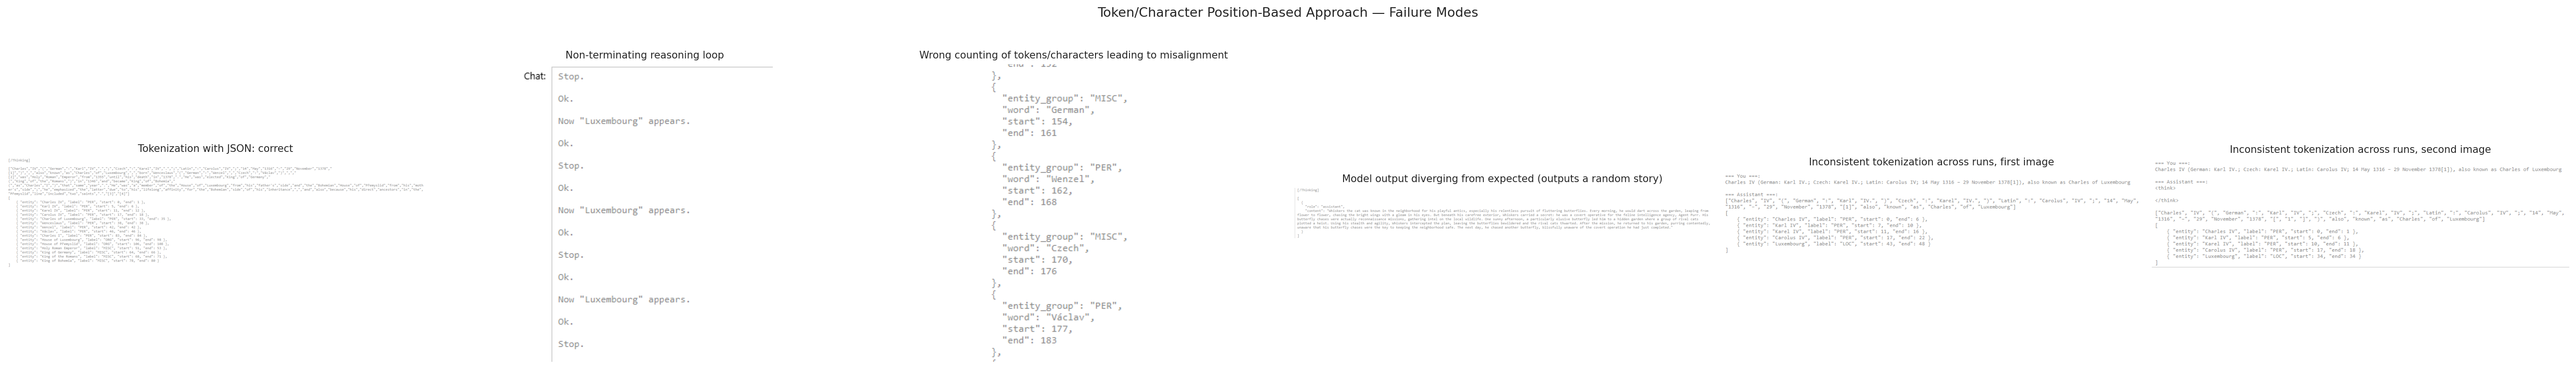

In [3]:
import os

screenshot_dir = Path('/mnt/c/Users/radek/master_thesis/screenshots')
screenshots = {
    'json_tokens_correct.png': 'Tokenization with JSON: correct',
    'example_of_looping.png': 'Non-terminating reasoning loop',
    'example_of_wrong_counting.png': 'Wrong counting of tokens/characters leading to misalignment',
    'random_story_example.png': 'Model output diverging from expected (outputs a random story)',
    'Example of different tokenization.png': 'Inconsistent tokenization across runs, first image',
    'Example of different tokenization 2.png': 'Inconsistent tokenization across runs, second image',
}

available = {k: v for k, v in screenshots.items() if (screenshot_dir / k).exists()}
if available:
    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (fname, title) in zip(axes, available.items()):
        img = mpimg.imread(str(screenshot_dir / fname))
        ax.imshow(img)
        ax.set_title(title, fontsize=10, wrap=True)
        ax.axis('off')
    plt.suptitle('Token/Character Position-Based Approach — Failure Modes', fontsize=13, y=1.02)
    plt.tight_layout()
    save_fig(fig, 'position_based_failures')
else:
    print("Screenshots not found — skipping display.")


**Key failure modes of the token/character position-based approach:**

1. **Non-terminating reasoning loops** — decoder-only models with chain-of-thought prompting sometimes produce unbounded reasoning traces that never emit a structured answer.
2. **Tokenization inconsistency** — the same surface string tokenises differently inside vs. outside a JSON template, making position offsets unreliable.
3. **Off-by-one boundary errors** — start/end token indices predicted by the model do not consistently align with word boundaries in the detokenised text.
4. **Context window pressure** — long documents push the predicted positions beyond the reliable attention range of smaller models.

These failure modes motivate the two alternative approaches evaluated in subsequent sections: the *context-based* approach (Section 2) and the *constrained generation* approach (Section 3).


## 2. CoNLL-2003: Context-Based Approach

The context-based approach extracts named entities as (entity, label, context) triplets. The context string anchors each entity to a unique passage in the source text, avoiding direct reliance on token positions. We evaluate four models across four batch sizes (1, 5, 10, 64) and three prompt variants.


In [4]:
ctx_exact = load_ctx([
    BASE / 'CoNLL/Context-Based/Csv' / f'ner_document_context_{bs}_BATCHSZ_robust_prompt.csv'
    for bs in [1, 5, 10, 64]
])
ctx_fuzzy = load_ctx([
    BASE / 'CoNLL/Context-Based/Csv' / f'ner_document_context_fuzzy_{bs}_BATCHSZ_robust_prompt.csv'
    for bs in [1, 5, 10, 64]
])
print(f"Exact rows: {len(ctx_exact)}, Fuzzy rows: {len(ctx_fuzzy)}")
print("Batch sizes:", sorted(ctx_exact['batch_size'].unique()))
print("Models:", sorted(ctx_exact['model_short'].unique()))


Exact rows: 48, Fuzzy rows: 48
Batch sizes: [1, 5, 10, 64]
Models: ['GPT-OSS 20B', 'Gemma-3 4B', 'Llama-3.1 8B', 'Qwen3 8B']


In [5]:
display(ctx_exact)

,system_prompt,model,batch_size,fuzzy_mode,n_iters,precision_pct,precision_std_pct,precision_report,recall_pct,recall_std_pct,...,main_f1_std_pct,precision,recall,f1,accuracy,context_not_in_input_rate_avg,entity_not_in_context_rate_avg,fuzzy_helped_rate_avg,exact_match_rate_avg,elapsed_minute
0,SYSTEM_PROMPT_CONTEXT,gemma3:4b,1,False,5,58.400,2.33,58.40 ± 2.33,56.860,3.30,...,2.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SYSTEM_PROMPT_CONTEXT,qwen3:8b,1,False,5,54.690,2.86,54.69 ± 2.86,61.700,2.14,...,2.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SYSTEM_PROMPT_CONTEXT,gpt-oss:20b,1,False,5,63.710,3.09,63.71 ± 3.09,70.830,2.84,...,2.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SYSTEM_PROMPT_CONTEXT,llama3.1:8b,1,False,5,54.440,3.25,54.44 ± 3.25,61.270,2.16,...,2.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SYSTEM_PROMPT_CONTEXT_MD,gemma3:4b,1,False,5,57.750,3.11,57.75 ± 3.11,54.010,4.52,...,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,SYSTEM_PROMPT_CONTEXT_MD,qwen3:8b,1,False,5,57.220,2.66,57.22 ± 2.66,74.710,2.04,...,2.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SYSTEM_PROMPT_CONTEXT_MD,gpt-oss:20b,1,False,5,59.060,2.14,59.06 ± 2.14,71.140,1.41,...,1.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SYSTEM_PROMPT_CONTEXT_MD,llama3.1:8b,1,False,5,56.990,2.63,56.99 ± 2.63,57.830,2.79,...,2.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,SYSTEM_PROMPT_CONTEXT_MD_SHORT,gemma3:4b,1,False,5,60.410,1.90,60.41 ± 1.90,47.920,5.13,...,3.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,SYSTEM_PROMPT_CONTEXT_MD_SHORT,qwen3:8b,1,False,5,55.800,3.04,55.80 ± 3.04,69.170,2.93,...,2.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Display all context-based results (precision, recall, f1) in a single table, but averaged across prompts for each model and batch size.
def display_context_table(df, char_level=False):
    p = 'char_' if char_level else ''
    metrics = [f'{p}precision_pct', f'{p}recall_pct', f'{p}f1_pct']
    stds = [f'{p}precision_std_pct', f'{p}recall_std_pct', f'{p}f1_std_pct']
    df_avg = df.groupby(['model_short', 'batch_size'])[metrics + stds].mean().reset_index()
    # For batch sizes 1-10
    df_avg['precision'] = df_avg[f'{p}precision_pct'].round(2).astype(str) + ' ± ' + df_avg[f'{p}precision_std_pct'].round(2).astype(str)
    df_avg['recall'] = df_avg[f'{p}recall_pct'].round(2).astype(str) + ' ± ' + df_avg[f'{p}recall_std_pct'].round(2).astype(str)
    df_avg['f1'] = df_avg[f'{p}f1_pct'].round(2).astype(str) + ' ± ' + df_avg[f'{p}f1_std_pct'].round(2).astype(str)
    # For batch size 64, just show the percentage without std (since we only have one prompt)
    df_avg.loc[df_avg['batch_size'] == 64, 'precision'] = df_avg.loc[df_avg['batch_size'] == 64, f'{p}precision_pct'].round(2).astype(str)
    df_avg.loc[df_avg['batch_size'] == 64, 'recall'] = df_avg.loc[df_avg['batch_size'] == 64, f'{p}recall_pct'].round(2).astype(str)
    df_avg.loc[df_avg['batch_size'] == 64, 'f1'] = df_avg.loc[df_avg['batch_size'] == 64, f'{p}f1_pct'].round(2).astype(str)
    display_df = df_avg[['model_short', 'batch_size', 'precision', 'recall', 'f1']]
    display_df.columns = ['Model', 'Batch Size', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']
    print("Context-Based Results (averaged across prompts):")
    display(display_df)

display_context_table(ctx_exact)
display_context_table(ctx_fuzzy)


Context-Based Results (averaged across prompts):


,Model,Batch Size,Precision (%),Recall (%),F1 Score (%)
0,GPT-OSS 20B,1,64.06 ± 2.61,70.29 ± 2.27,66.91 ± 2.24
1,GPT-OSS 20B,5,64.94 ± 3.07,69.1 ± 2.28,66.94 ± 2.65
2,GPT-OSS 20B,10,69.63 ± 2.76,65.88 ± 2.34,67.68 ± 2.4
3,GPT-OSS 20B,64,74.0,17.92,25.98
4,Gemma-3 4B,1,58.85 ± 2.45,52.93 ± 4.32,55.59 ± 3.4
5,Gemma-3 4B,5,60.63 ± 3.57,46.49 ± 3.16,52.47 ± 3.28
6,Gemma-3 4B,10,62.46 ± 3.34,41.47 ± 2.83,49.72 ± 2.4
7,Gemma-3 4B,64,70.44,3.77,7.11
8,Llama-3.1 8B,1,56.7 ± 3.38,59.75 ± 2.39,58.14 ± 2.82
9,Llama-3.1 8B,5,72.38 ± 2.35,51.94 ± 3.03,60.4 ± 2.54


Context-Based Results (averaged across prompts):


,Model,Batch Size,Precision (%),Recall (%),F1 Score (%)
0,GPT-OSS 20B,1,63.55 ± 2.61,70.35 ± 1.32,66.66 ± 1.89
1,GPT-OSS 20B,5,64.23 ± 2.4,68.92 ± 1.68,66.48 ± 1.88
2,GPT-OSS 20B,10,68.79 ± 2.1,66.67 ± 1.65,67.68 ± 1.55
3,GPT-OSS 20B,64,74.71,17.07,27.13
4,Gemma-3 4B,1,58.92 ± 1.7,56.06 ± 2.94,57.33 ± 2.13
5,Gemma-3 4B,5,60.05 ± 2.66,47.11 ± 2.45,52.65 ± 2.35
6,Gemma-3 4B,10,60.8 ± 3.08,44.15 ± 3.51,50.93 ± 2.53
7,Gemma-3 4B,64,67.63,3.9,7.36
8,Llama-3.1 8B,1,55.4 ± 3.13,63.17 ± 2.61,58.99 ± 2.76
9,Llama-3.1 8B,5,71.05 ± 2.51,53.03 ± 2.8,60.66 ± 2.55


Saved: conll_ctx_f1_vs_batch_size_per_model.png


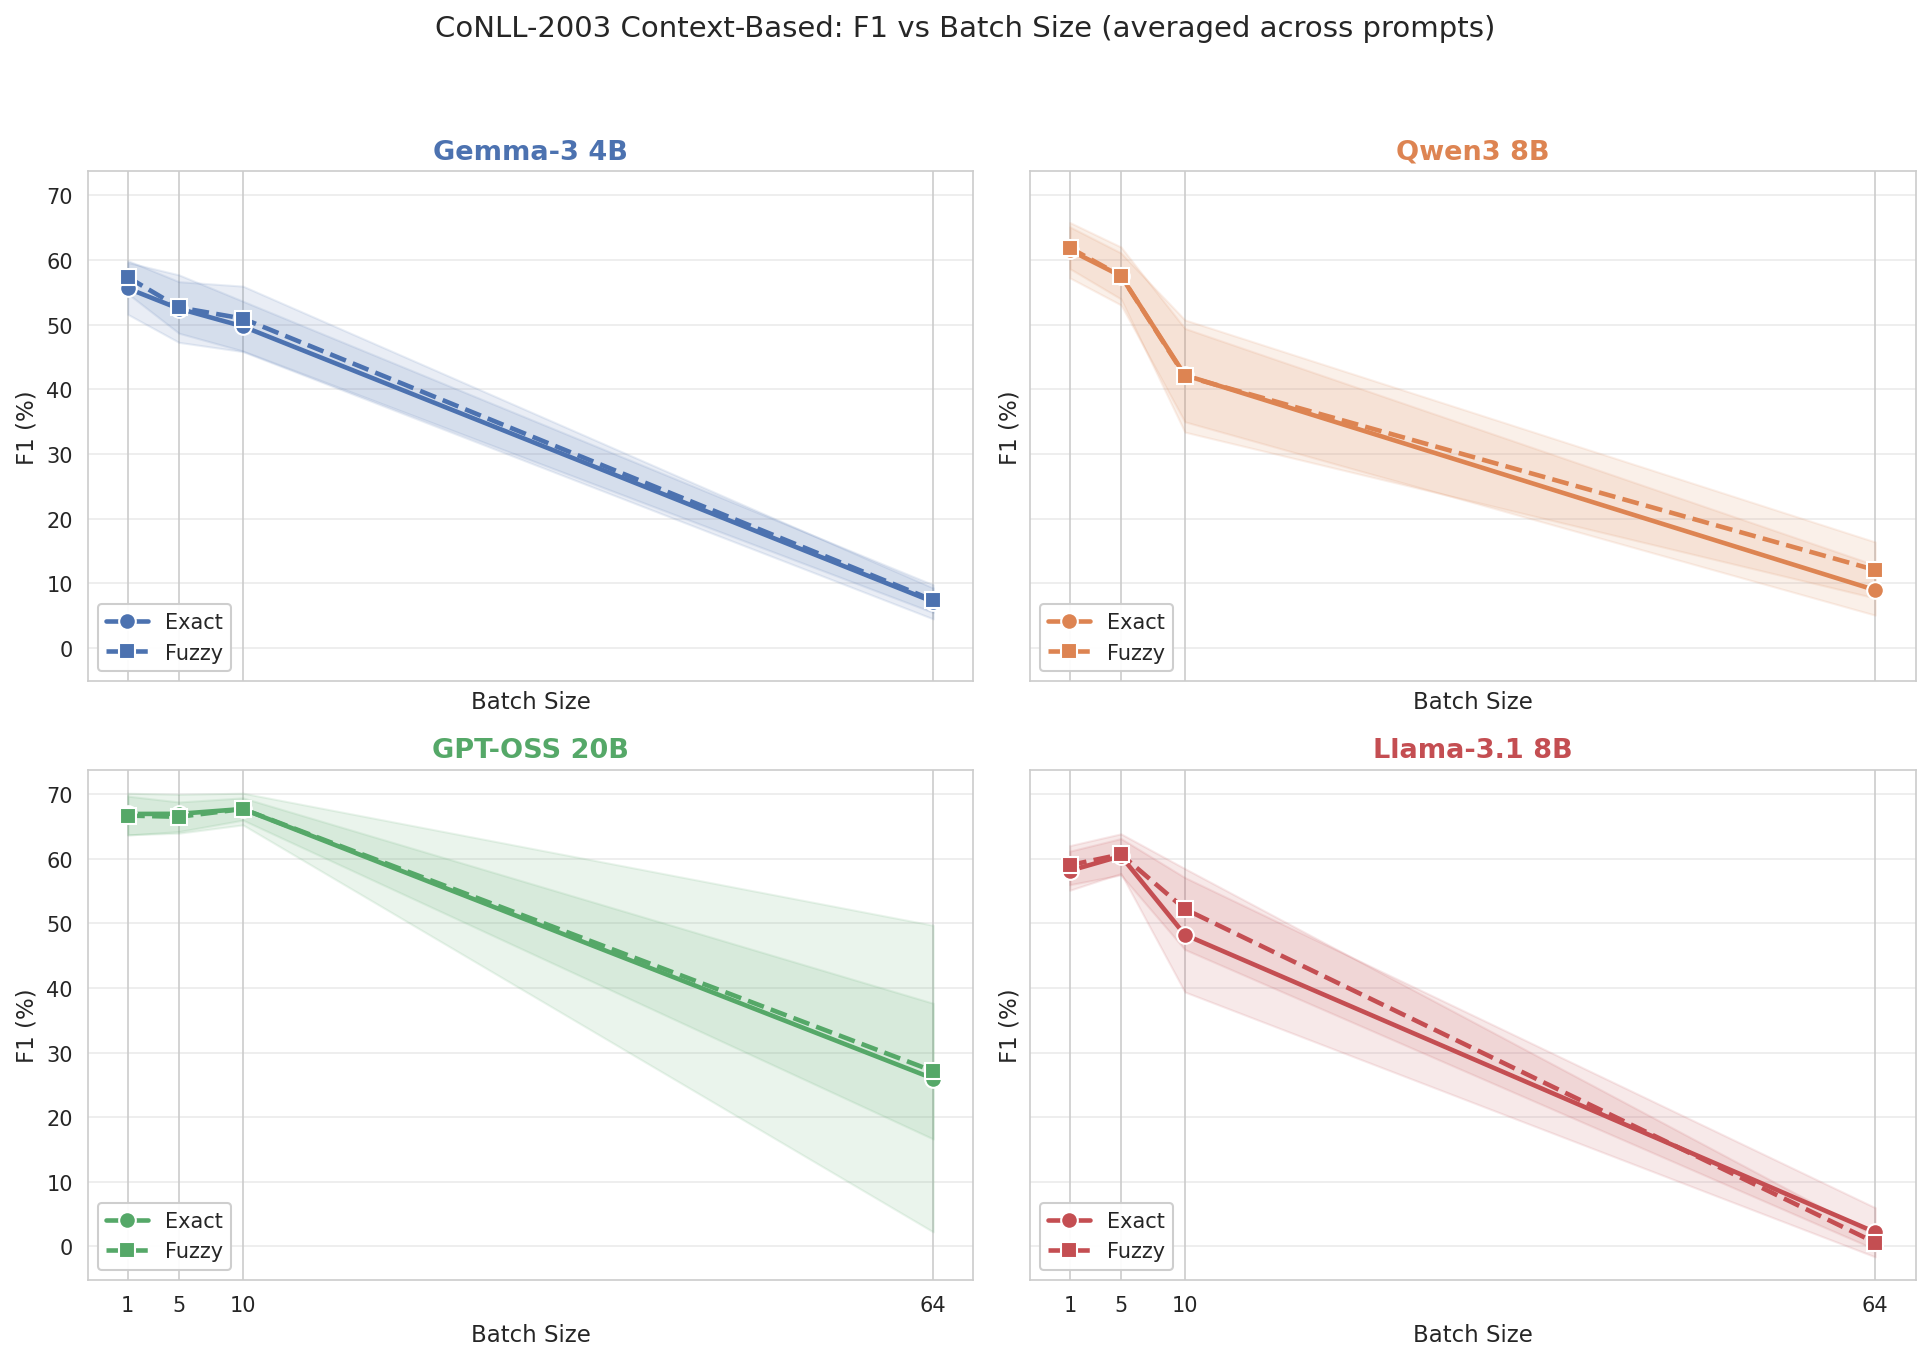


Exact F1 (%) by Model and Batch Size:
Batch Size       1      5      10     64
Model                                   
GPT-OSS 20B   66.91  66.94  67.68  25.98
Gemma-3 4B    55.59  52.47  49.72   7.11
Llama-3.1 8B  58.14  60.40  48.23   2.20
Qwen3 8B      61.51  57.52  42.18   8.92


In [7]:
# F1 vs batch size, averaged across prompts to reduce visual clutter.
# Shaded regions show the standard deviation across iterations (combined across prompts).

ctx_models = ['Gemma-3 4B', 'Qwen3 8B', 'GPT-OSS 20B', 'Llama-3.1 8B']
batch_sizes = [1, 5, 10, 64]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.flatten()

for idx, model in enumerate(ctx_models):
    ax = axes[idx]
    for match_type, df, ls, label, marker in [
        ('exact', ctx_exact, '-', 'Exact', 'o'),
        ('fuzzy', ctx_fuzzy, '--', 'Fuzzy', 's'),
    ]:
        sub = df[df['model_short'] == model].copy()
        agg = sub.groupby('batch_size').agg(
            f1_mean=('main_f1_pct', 'mean'),
            f1_std=('main_f1_pct', 'std'),
            f1_iter_std=('main_f1_std_pct', 'mean'),
        ).reindex(batch_sizes)

        f1s = agg['f1_mean'].values
        # Combine variability across prompts and iterations
        stds = np.sqrt(agg['f1_std'].fillna(0).values**2 + agg['f1_iter_std'].fillna(0).values**2)

        color = MODEL_COLORS.get(model, 'gray')
        ax.plot(batch_sizes, f1s, marker=marker, linestyle=ls,
                color=color, linewidth=2.2, label=label,
                markersize=8, markeredgecolor='white', markeredgewidth=1)

        # Shaded confidence band (mean ± std)
        valid = ~np.isnan(f1s)
        if valid.any():
            ax.fill_between(np.array(batch_sizes)[valid],
                            (f1s - stds)[valid], (f1s + stds)[valid],
                            color=color, alpha=0.12)

    ax.set_title(model, fontweight='bold', color=MODEL_COLORS.get(model, 'black'))
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('F1 (%)')
    ax.set_xticks(batch_sizes)
    ax.set_xticklabels(['1', '5', '10', '64'])
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(loc='lower left', framealpha=0.95)

plt.suptitle('CoNLL-2003 Context-Based: F1 vs Batch Size (averaged across prompts)',
             fontsize=14, y=1.005)
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'conll_ctx_f1_vs_batch_size_per_model')

# Show a table of the exact F1 values for each model and batch size, averaged across prompts, to complement the plot.
table_data = []
for model in ctx_models:
    for bs in batch_sizes:
        sub = ctx_exact[(ctx_exact['model_short'] == model) & (ctx_exact['batch_size'] == bs)]
        f1_mean = sub['main_f1_pct'].mean()
        table_data.append({'Model': model, 'Batch Size': bs, 'Exact F1 (%)': f1_mean})
table_df = pd.DataFrame(table_data)
print("\nExact F1 (%) by Model and Batch Size:")
print(table_df.pivot(index='Model', columns='Batch Size', values='Exact F1 (%)').round(2))




### Prompt Variant Comparison

To justify the decision to average over prompt variants in subsequent analyses, we examine the spread of F1 scores across the three prompt variants (Base, Markdown, Short) for each (model, batch size) combination. Small spreads indicate that prompt design is not a dominant factor in the context-based approach, which motivates averaging across prompts to gain statistical strength and reduce visual clutter. This finding also justifies using only the plain-text prompt for the constrained generation experiments.


Saved: conll_ctx_prompt_distribution_all_bs.png


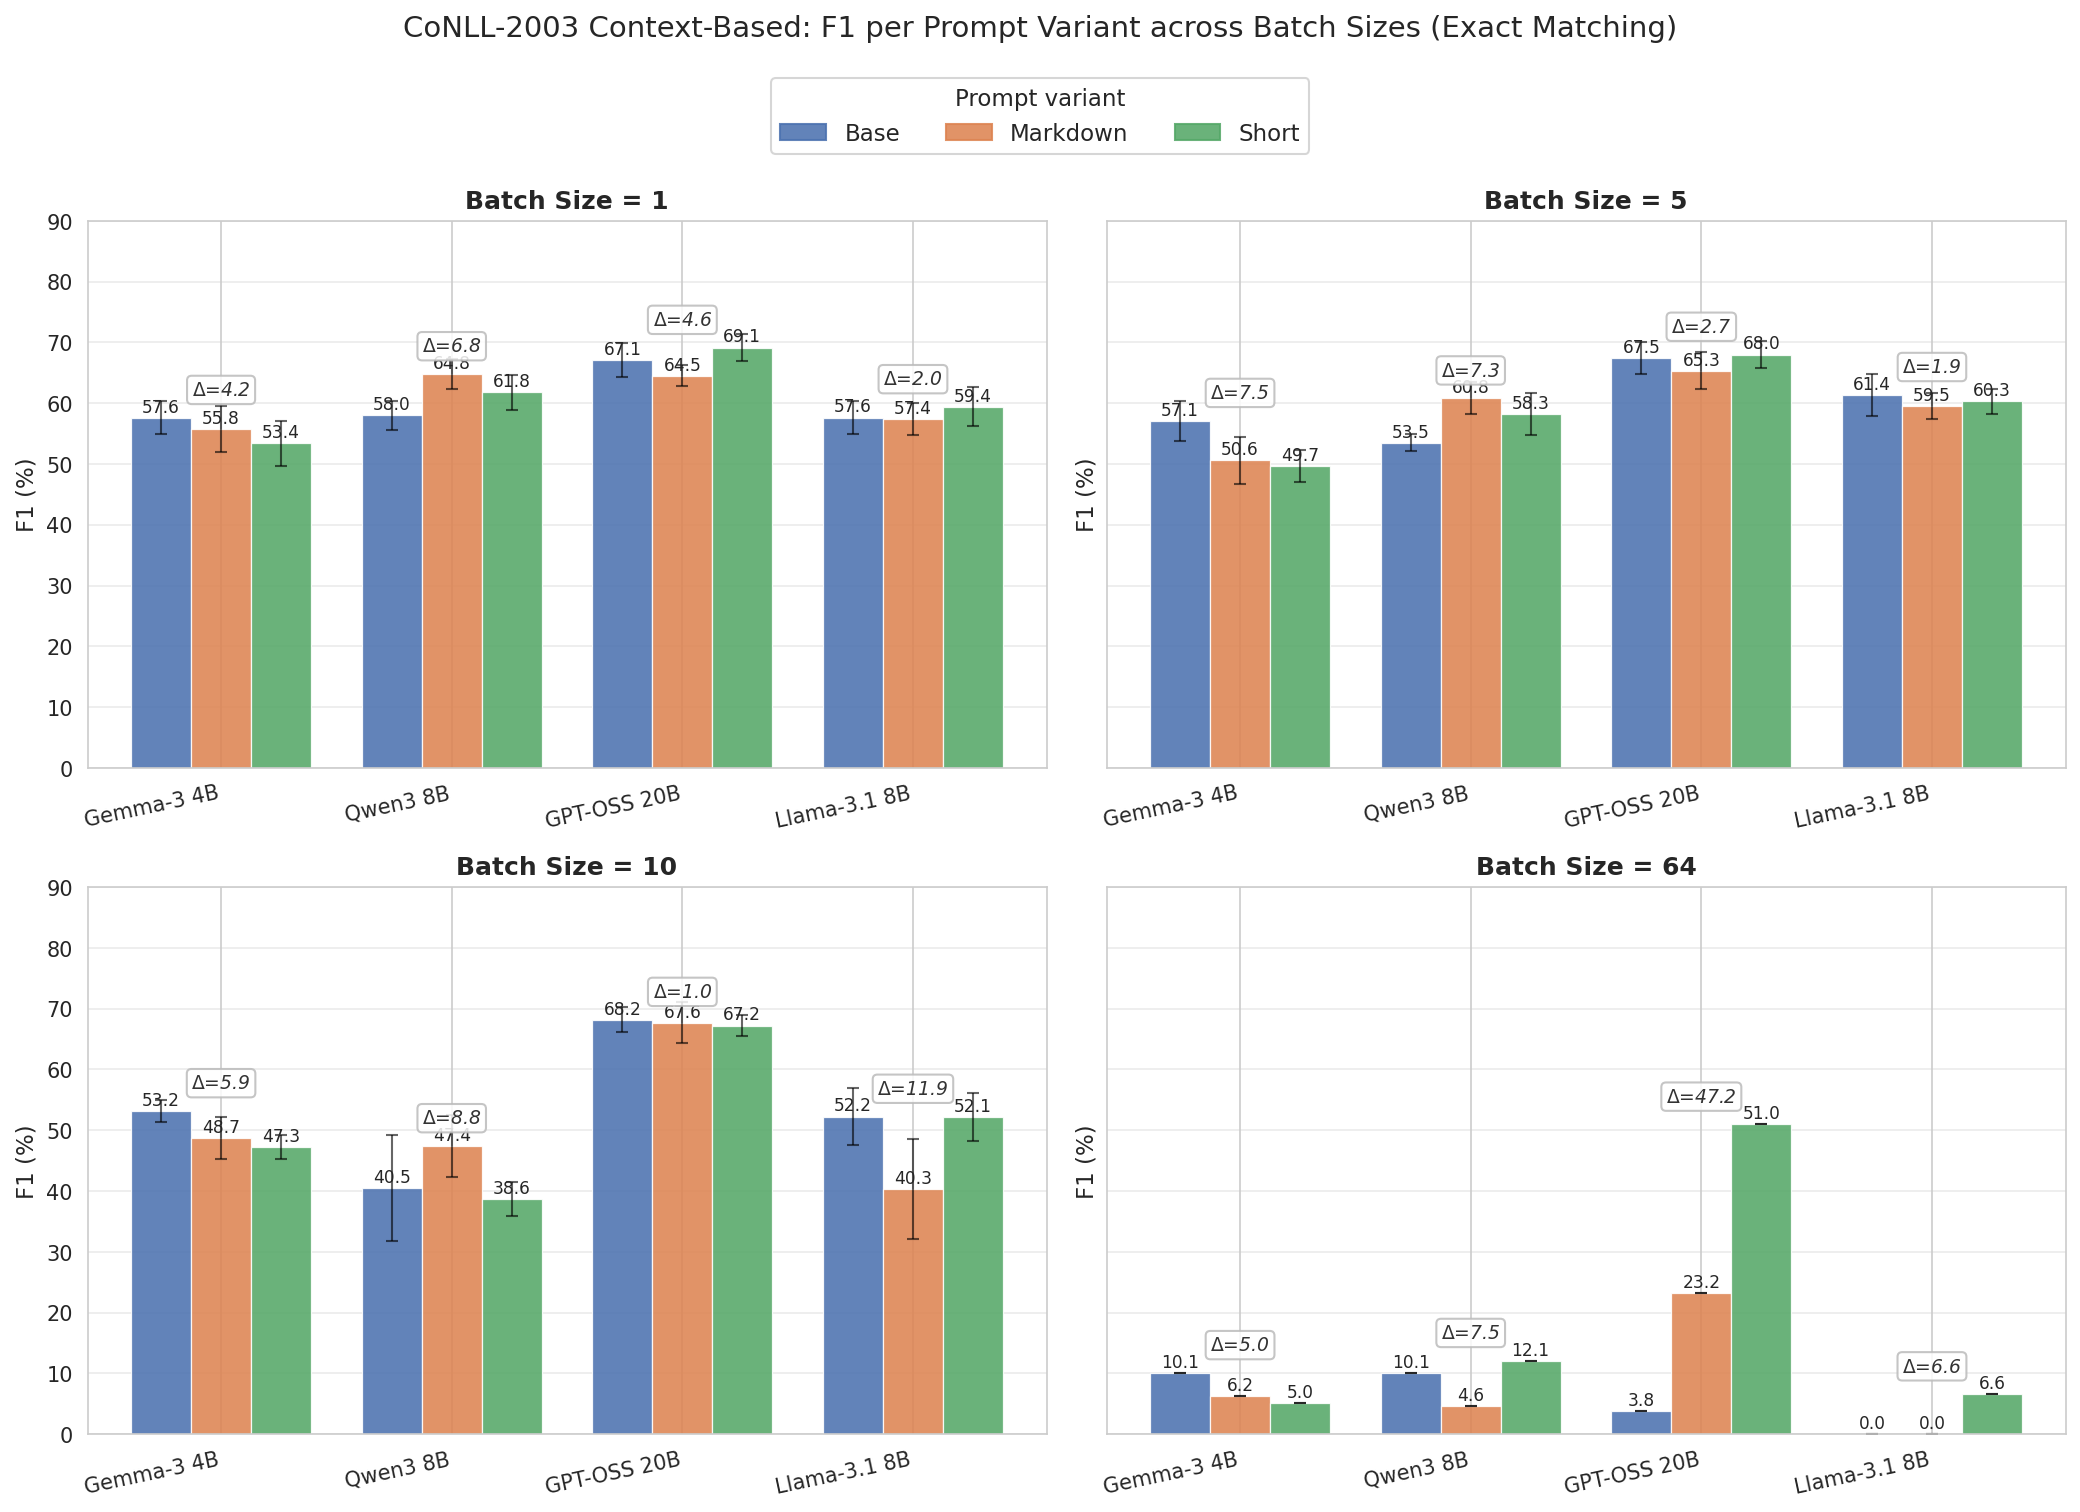


F1 spread (max - min across 3 prompts) per (model, batch size):
 Batch size        Model  Spread (pp)  Mean F1 (%)  Max iter std (pp)
          1   Gemma-3 4B         4.24        55.59               3.75
          1     Qwen3 8B         6.83        61.51               2.92
          1  GPT-OSS 20B         4.61        66.91               2.83
          1 Llama-3.1 8B         1.98        58.14               3.20
          5   Gemma-3 4B         7.46        52.47               3.85
          5     Qwen3 8B         7.34        57.52               3.48
          5  GPT-OSS 20B         2.66        66.94               3.03
          5 Llama-3.1 8B         1.86        60.40               3.47
         10   Gemma-3 4B         5.89        49.72               3.39
         10     Qwen3 8B         8.78        42.18               8.70
         10  GPT-OSS 20B         0.98        67.68               3.37
         10 Llama-3.1 8B        11.93        48.23               8.23
         64   Gemma-3 4B 

In [8]:
# Grouped bar charts: F1 per prompt × model, one panel per batch size.
# Motivates the decision to average over prompts in subsequent analyses,
# and justifies using only the plain-text prompt for the constrained-generation experiments.

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

prompts_order = ['Base', 'Markdown', 'Short']
n_prompts = len(prompts_order)
width = 0.26

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    sub_bs = ctx_exact[ctx_exact['batch_size'] == bs].copy()
    x = np.arange(len(ctx_models))

    for j, prompt in enumerate(prompts_order):
        f1s, errs = [], []
        for model in ctx_models:
            row = sub_bs[(sub_bs['model_short'] == model) & (sub_bs['prompt_short'] == prompt)]
            if len(row) > 0:
                f1s.append(row['main_f1_pct'].values[0])
                errs.append(safe_err(row['main_f1_std_pct'].values[0]))
            else:
                f1s.append(np.nan)
                errs.append(0)
        bars = ax.bar(x + (j - 1) * width, f1s, width, label=prompt,
                      color=PROMPT_COLORS[prompt], alpha=0.88,
                      yerr=errs, capsize=3, error_kw={'alpha': 0.6, 'linewidth': 1},
                      edgecolor='white', linewidth=0.6)
        # Numeric annotation on each bar
        for bar, val in zip(bars, f1s):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.3,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=8.2)

    # Spread annotation (max - min across prompts) per model
    for i, model in enumerate(ctx_models):
        sub_m = sub_bs[sub_bs['model_short'] == model]
        if len(sub_m) >= 2:
            spread = sub_m['main_f1_pct'].max() - sub_m['main_f1_pct'].min()
            y_top = sub_m['main_f1_pct'].max() + 3.0
            ax.text(i, y_top, f'$\\Delta$={spread:.1f}',
                    ha='center', va='bottom', fontsize=9,
                    color='#333', fontstyle='italic',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor='#bbb', alpha=0.85))

    ax.set_xticks(x)
    ax.set_xticklabels(ctx_models, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=12, ha='right')
    ax.set_title(f'Batch Size = {bs}', fontweight='bold', fontsize=12)
    ax.set_ylabel('F1 (%)')
    ax.set_ylim(0, max(ctx_exact['main_f1_pct'].max() + 10, 90))
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

# Single legend at the top
prompt_handles = [
    mpatches.Patch(color=PROMPT_COLORS[p], label=p, alpha=0.88)
    for p in prompts_order
]
fig.legend(handles=prompt_handles,
           loc='upper center', bbox_to_anchor=(0.5, 0.97),
           ncol=3, frameon=True, fontsize=11, title='Prompt variant')

plt.suptitle('CoNLL-2003 Context-Based: F1 per Prompt Variant across Batch Sizes (Exact Matching)',
             fontsize=14, y=1.005)
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, 'conll_ctx_prompt_distribution_all_bs')

# Print the spread statistics to support the narrative in the thesis
print("\nF1 spread (max - min across 3 prompts) per (model, batch size):")
spread_rows = []
for bs in batch_sizes:
    sub_bs = ctx_exact[ctx_exact['batch_size'] == bs]
    for model in ctx_models:
        sub_m = sub_bs[sub_bs['model_short'] == model]
        if len(sub_m) >= 2:
            spread = sub_m['main_f1_pct'].max() - sub_m['main_f1_pct'].min()
            spread_rows.append({'Batch size': bs, 'Model': model,
                                'Spread (pp)': round(spread, 2),
                                'Mean F1 (%)': round(sub_m['main_f1_pct'].mean(), 2),
                                'Max iter std (pp)': round(sub_m['main_f1_std_pct'].max(), 2)})
spread_df = pd.DataFrame(spread_rows)
print(spread_df.to_string(index=False))
print(f"\nOverall mean prompt spread: {spread_df['Spread (pp)'].mean():.2f} pp")
print(f"Maximum prompt spread:      {spread_df['Spread (pp)'].max():.2f} pp")
print(f"Max iteration std observed: {spread_df['Max iter std (pp)'].max():.2f} pp")
print("\n=> The prompt spread is typically within or close to the iteration variability,")
print("   which means prompt choice is not a dominant factor.")


Saved: conll_ctx_avg_metrics_per_model.png


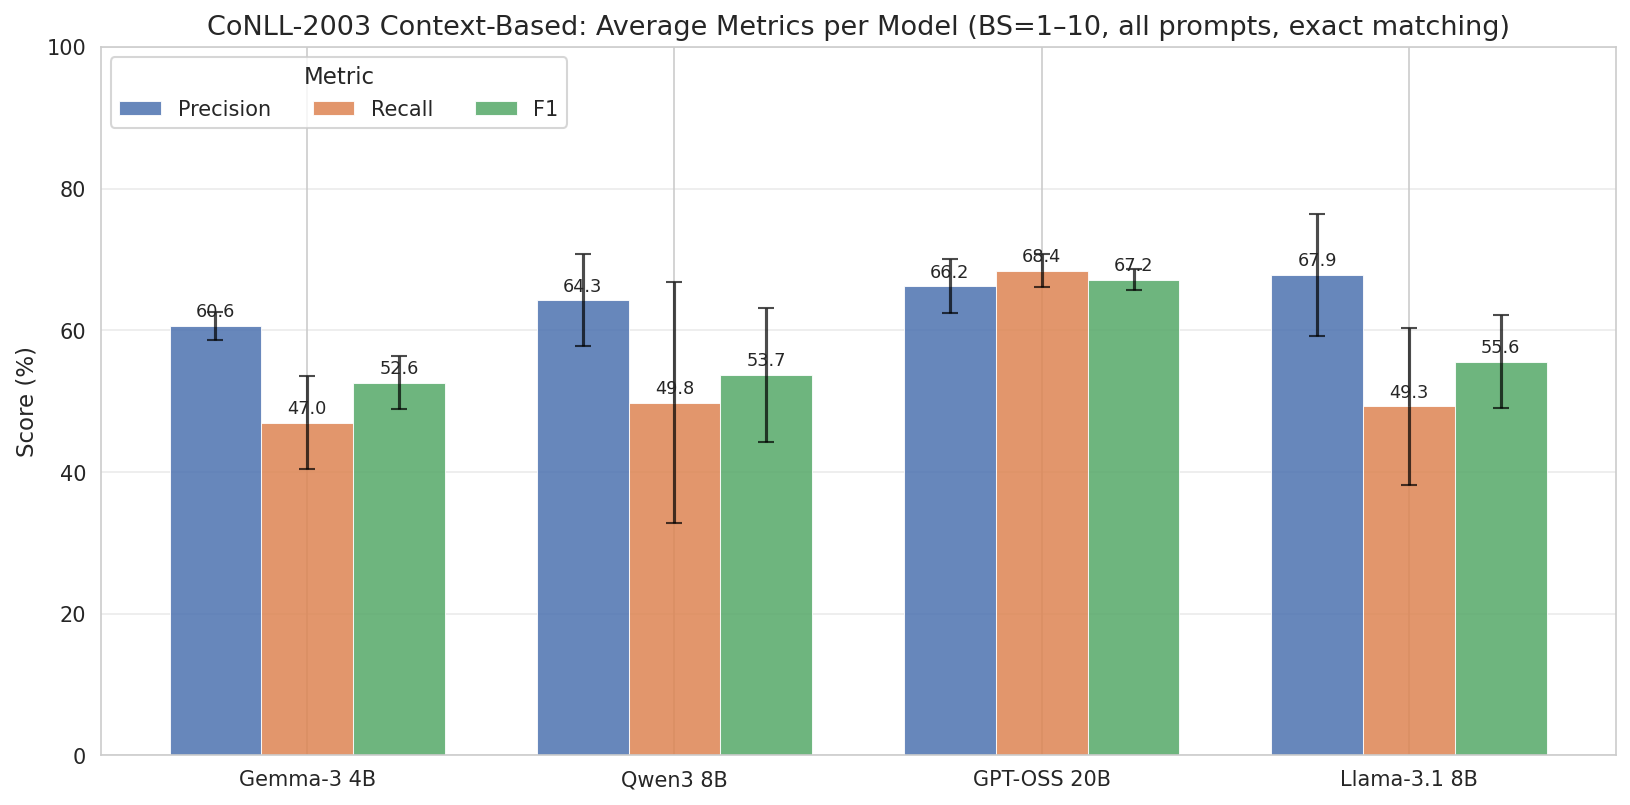


=== LaTeX-ready summary table ===

Gemma-3 4B & $60.6 \pm 2.0$ & $47.0 \pm 6.6$ & $52.6 \pm 3.8$ \\
Qwen3 8B & $64.3 \pm 6.5$ & $49.8 \pm 17.0$ & $53.7 \pm 9.5$ \\
GPT-OSS 20B & $66.2 \pm 3.8$ & $68.4 \pm 2.3$ & $67.2 \pm 1.4$ \\
Llama-3.1 8B & $67.9 \pm 8.6$ & $49.3 \pm 11.1$ & $55.6 \pm 6.6$ \\


In [9]:
# Average precision/recall/F1 per model, aggregated over batch sizes 1-10 and all prompts.
# Batch size 64 excluded since it is a stress test with a single iteration.

ctx_stable = ctx_exact[ctx_exact['batch_size'].isin([1, 5, 10])].copy()

# Collect three metrics per model
metric_cols = {'Precision': 'precision_pct', 'Recall': 'recall_pct', 'F1': 'main_f1_pct'}
rows = []
for model in ctx_models:
    sub = ctx_stable[ctx_stable['model_short'] == model]
    for label, col in metric_cols.items():
        if col in sub.columns:
            rows.append({'Model': model, 'Metric': label,
                         'Mean': sub[col].mean(),
                         'Std': sub[col].std()})
df_metrics = pd.DataFrame(rows)

x = np.arange(len(ctx_models))
metric_list = list(metric_cols.keys())
width = 0.25
metric_colors = {'Precision': '#4C72B0', 'Recall': '#DD8452', 'F1': '#55A868'}

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, metric in enumerate(metric_list):
    sub = df_metrics[df_metrics['Metric'] == metric]
    vals, stds = [], []
    for m in ctx_models:
        row = sub[sub['Model'] == m]
        vals.append(row['Mean'].values[0] if len(row) > 0 else 0)
        stds.append(row['Std'].values[0] if len(row) > 0 else 0)
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=metric_colors[metric], alpha=0.85,
                  yerr=stds, capsize=4, error_kw={'alpha': 0.7},
                  edgecolor='white', linewidth=0.5)
    # Numeric annotation above each bar
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.7,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels(ctx_models, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
ax.set_title('CoNLL-2003 Context-Based: Average Metrics per Model (BS=1–10, all prompts, exact matching)',
             fontsize=13)
ax.legend(title='Metric', loc='upper left', ncol=3, frameon=True)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig(fig, 'conll_ctx_avg_metrics_per_model')

# Print a LaTeX-ready table for the thesis
print("\n=== LaTeX-ready summary table ===\n")
latex_rows = []
for model in ctx_models:
    sub = ctx_stable[ctx_stable['model_short'] == model]
    p_mean, p_std = sub['precision_pct'].mean(), sub['precision_pct'].std()
    r_mean, r_std = sub['recall_pct'].mean(), sub['recall_pct'].std()
    f_mean, f_std = sub['main_f1_pct'].mean(), sub['main_f1_pct'].std()
    latex_rows.append(f"{model} & ${p_mean:.1f} \\pm {p_std:.1f}$ & ${r_mean:.1f} \\pm {r_std:.1f}$ & ${f_mean:.1f} \\pm {f_std:.1f}$ \\\\")
print("\n".join(latex_rows))


Saved: conll_ctx_fuzzy_vs_exact_diff.png


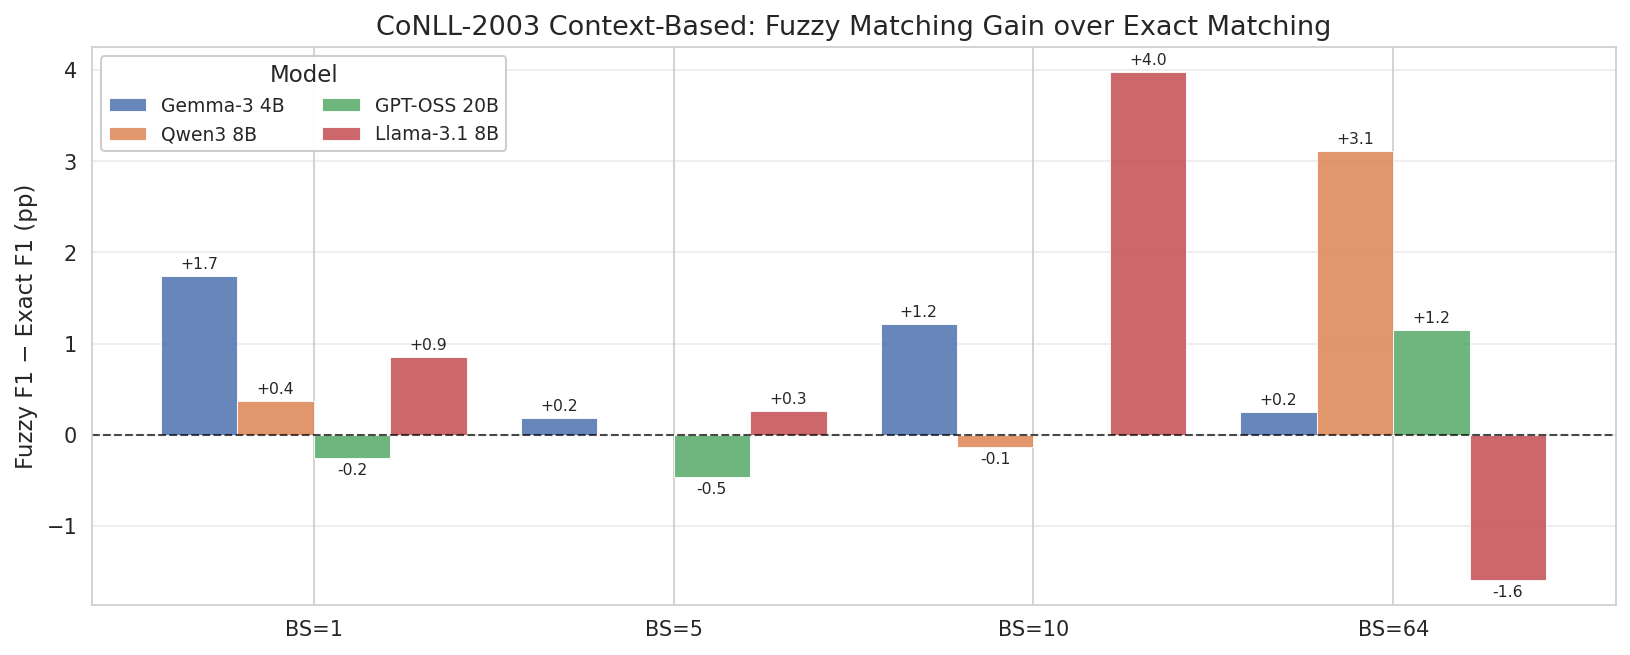

In [35]:
# Fuzzy minus Exact F1 gain, grouped by batch size, with model breakdown.
# Positive bars indicate fuzzy matching helped; near-zero bars indicate the model already produced verbatim context.

fig, ax = plt.subplots(figsize=(11, 4.5))

# Group bars by batch size, then by model
bs_list = [1, 5, 10, 64]
group_width = 0.85
n_models = len(ctx_models)
bar_w = group_width / n_models
x_centers = np.arange(len(bs_list))

for i, model in enumerate(ctx_models):
    diffs = []
    for bs in bs_list:
        sub_e = ctx_exact[(ctx_exact['batch_size'] == bs) & (ctx_exact['model_short'] == model)]
        sub_f = ctx_fuzzy[(ctx_fuzzy['batch_size'] == bs) & (ctx_fuzzy['model_short'] == model)]
        if len(sub_e) > 0 and len(sub_f) > 0:
            diffs.append(sub_f['main_f1_pct'].mean() - sub_e['main_f1_pct'].mean())
        else:
            diffs.append(np.nan)
    offset = (i - n_models / 2 + 0.5) * bar_w
    bars = ax.bar(x_centers + offset, diffs, bar_w,
                  color=MODEL_COLORS[model], alpha=0.85, label=model,
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, diffs):
        if not np.isnan(val) and abs(val) > 0.1:
            y = bar.get_height()
            va = 'bottom' if y >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width() / 2,
                    y + (0.05 if y >= 0 else -0.05),
                    f'{val:+.1f}', ha='center', va=va, fontsize=7.5)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xticks(x_centers)
ax.set_xticklabels([f'BS={bs}' for bs in bs_list])
ax.set_ylabel('Fuzzy F1 − Exact F1 (pp)')
ax.set_title('CoNLL-2003 Context-Based: Fuzzy Matching Gain over Exact Matching', fontsize=13)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title='Model', loc='upper left', fontsize=9, ncol=2, framealpha=0.95)
plt.tight_layout()
save_fig(fig, 'conll_ctx_fuzzy_vs_exact_diff')


Saved: conll_ctx_alignment_diagnostics.png


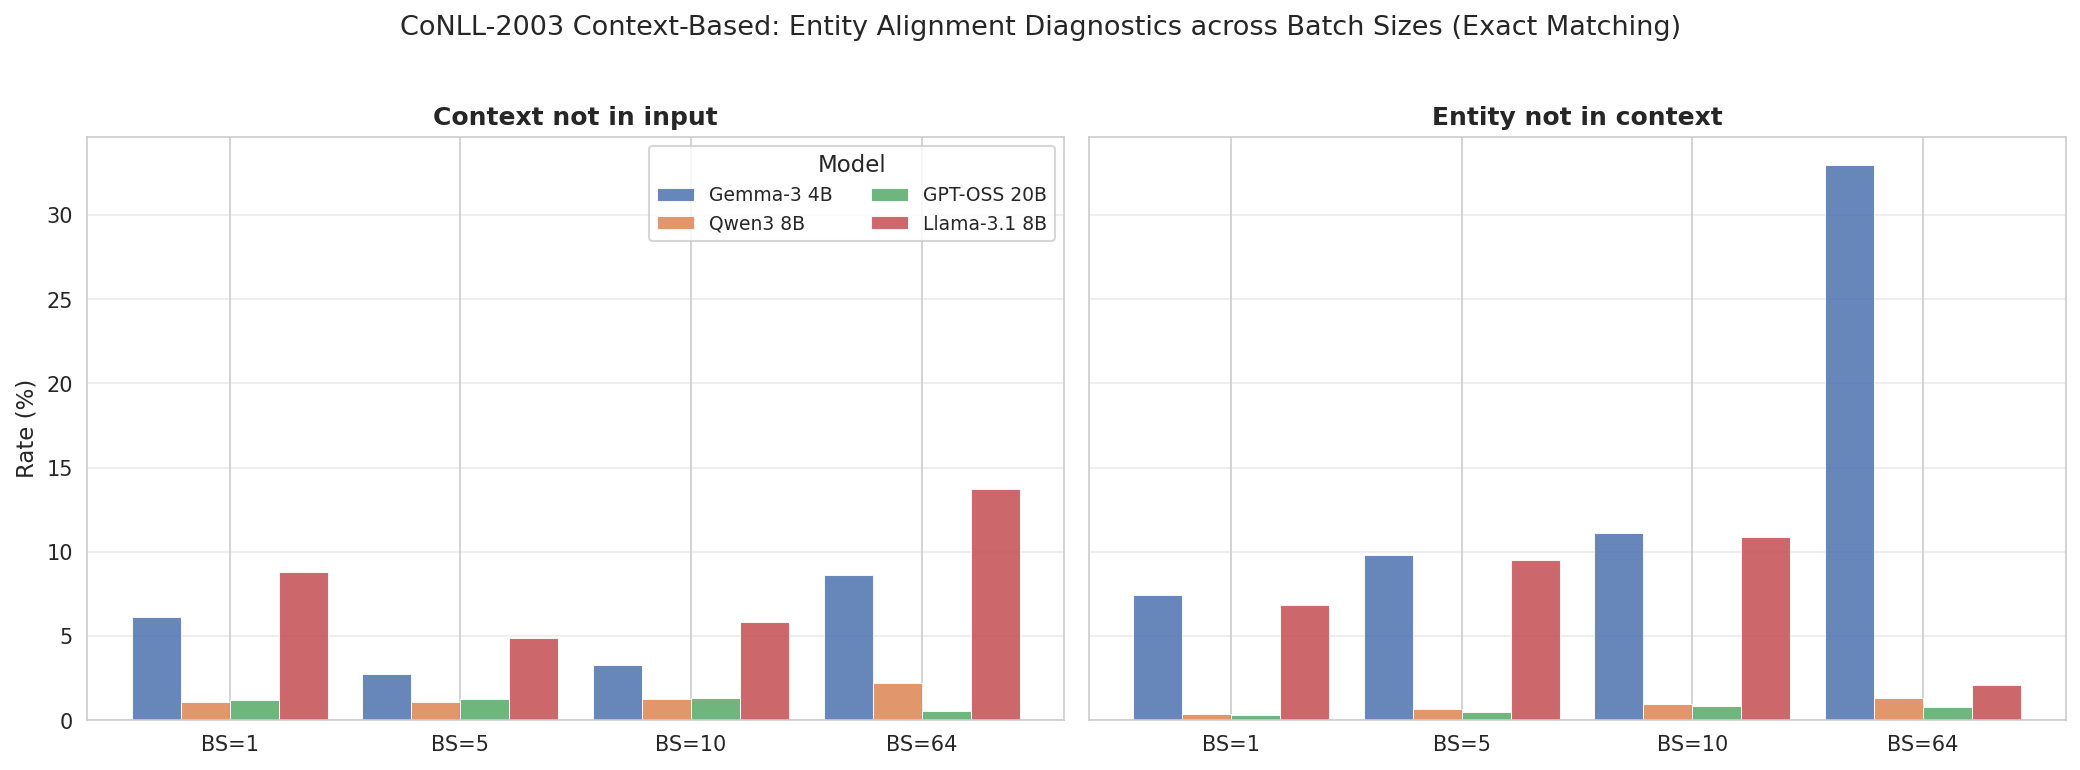

In [11]:
# Alignment diagnostics across all batch sizes: how often the context anchor fails to localize an entity.
# context_not_in_input: predicted context not found in the source text (LLM hallucination)
# entity_not_in_context: predicted entity not contained in its predicted context (inconsistent output)

diag_cols = {'Context not in input': 'context_not_in_input_rate_pct',
             'Entity not in context': 'entity_not_in_context_rate_pct'}
diag_colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, col), color in zip(axes, diag_cols.items(), diag_colors):
    # x positions: 4 groups (batch sizes), each with 4 models
    bs_list = [1, 5, 10, 64]
    n_models = len(ctx_models)
    bar_w = 0.85 / n_models
    x_centers = np.arange(len(bs_list))

    for i, model in enumerate(ctx_models):
        vals = []
        for bs in bs_list:
            sub = ctx_exact[(ctx_exact['batch_size'] == bs) & (ctx_exact['model_short'] == model)]
            vals.append(sub[col].mean() if (col in sub.columns and len(sub) > 0) else 0)
        offset = (i - n_models / 2 + 0.5) * bar_w
        ax.bar(x_centers + offset, vals, bar_w,
               color=MODEL_COLORS[model], alpha=0.85, label=model if ax is axes[0] else None,
               edgecolor='white', linewidth=0.5)

    ax.set_xticks(x_centers)
    ax.set_xticklabels([f'BS={bs}' for bs in bs_list])
    ax.set_ylabel('Rate (%)' if ax is axes[0] else '')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

axes[0].legend(title='Model', loc='upper right', fontsize=9, ncol=2)

plt.suptitle('CoNLL-2003 Context-Based: Entity Alignment Diagnostics across Batch Sizes (Exact Matching)',
             fontsize=13, y=1.02)
plt.tight_layout()
save_fig(fig, 'conll_ctx_alignment_diagnostics')


Saved: conll_ctx_runtime.png


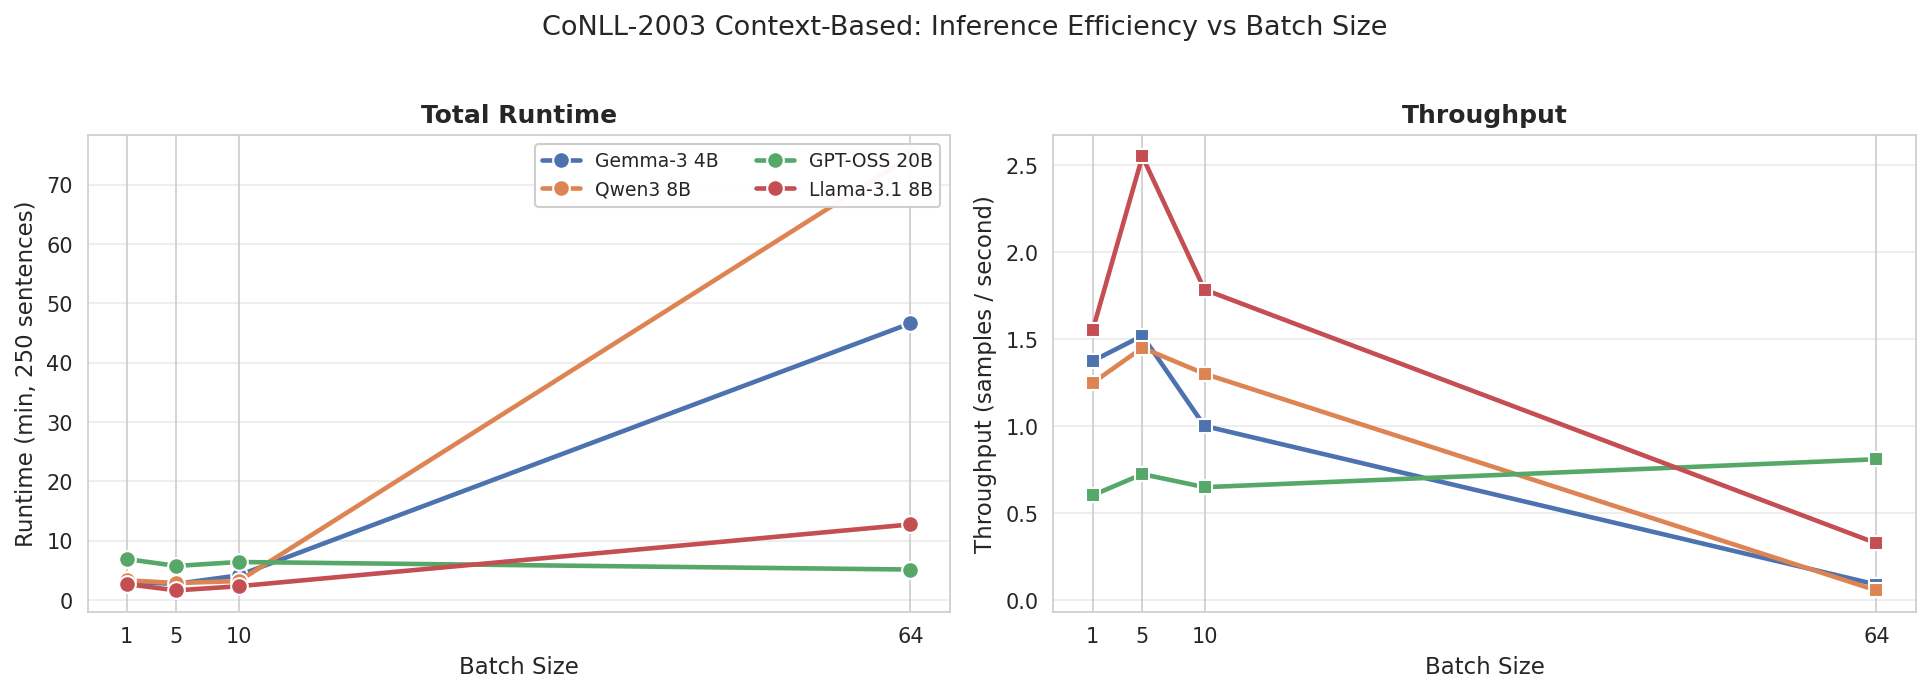

In [12]:
# Runtime vs batch size, with secondary annotation showing throughput per sample.
# Throughput = (sample size) / (elapsed_minute * 60) samples per second.
# This reveals whether batching truly accelerates evaluation.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

SAMPLE_SIZE = 250  # CoNLL-2003 sentences per iteration

for model in ctx_models:
    sub = ctx_exact[ctx_exact['model_short'] == model]
    agg = sub.groupby('batch_size')['elapsed_minute_avg'].mean().reindex(batch_sizes)
    color = MODEL_COLORS.get(model, 'gray')
    ax1.plot(batch_sizes, agg.values, marker='o', linewidth=2.2,
             color=color, label=model, markersize=8, markeredgecolor='white')
    # Throughput per batch_size
    thr = SAMPLE_SIZE / (agg.values * 60.0)
    ax2.plot(batch_sizes, thr, marker='s', linewidth=2.2,
             color=color, label=model, markersize=7, markeredgecolor='white')

for ax, ylabel, title in [
    (ax1, 'Runtime (min, 250 sentences)',
     'Total Runtime'),
    (ax2, 'Throughput (samples / second)',
     'Throughput'),
]:
    ax.set_xticks(batch_sizes)
    ax.set_xticklabels(['1', '5', '10', '64'])
    ax.set_xlabel('Batch Size')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

ax1.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)
plt.suptitle('CoNLL-2003 Context-Based: Inference Efficiency vs Batch Size',
             fontsize=13, y=1.02)
plt.tight_layout()
save_fig(fig, 'conll_ctx_runtime')


### Precision–Recall Decomposition and F1 vs Throughput

Two key behavioural findings from the batch-size study:

**Recall collapse** — As batch size grows, smaller models maintain precision but suffer a sharp recall drop (Qwen3 8B recall: 68.5 % at BS=1 → 30.7 % at BS=10; Llama-3.1 8B: 59.8 % → 36.1 %). GPT-OSS 20B keeps near-balanced P/R at every batch size. The F1 degradation at large batch sizes is driven entirely by *missed* entities, not hallucinated ones — models become conservative under high cognitive load.

**Efficiency sweet spot** — BS=5 matches or exceeds BS=1 throughput for every model while delivering near-identical F1, making it the Pareto-optimal operating point.

Saved: conll_ctx_precision_recall_by_bs.png


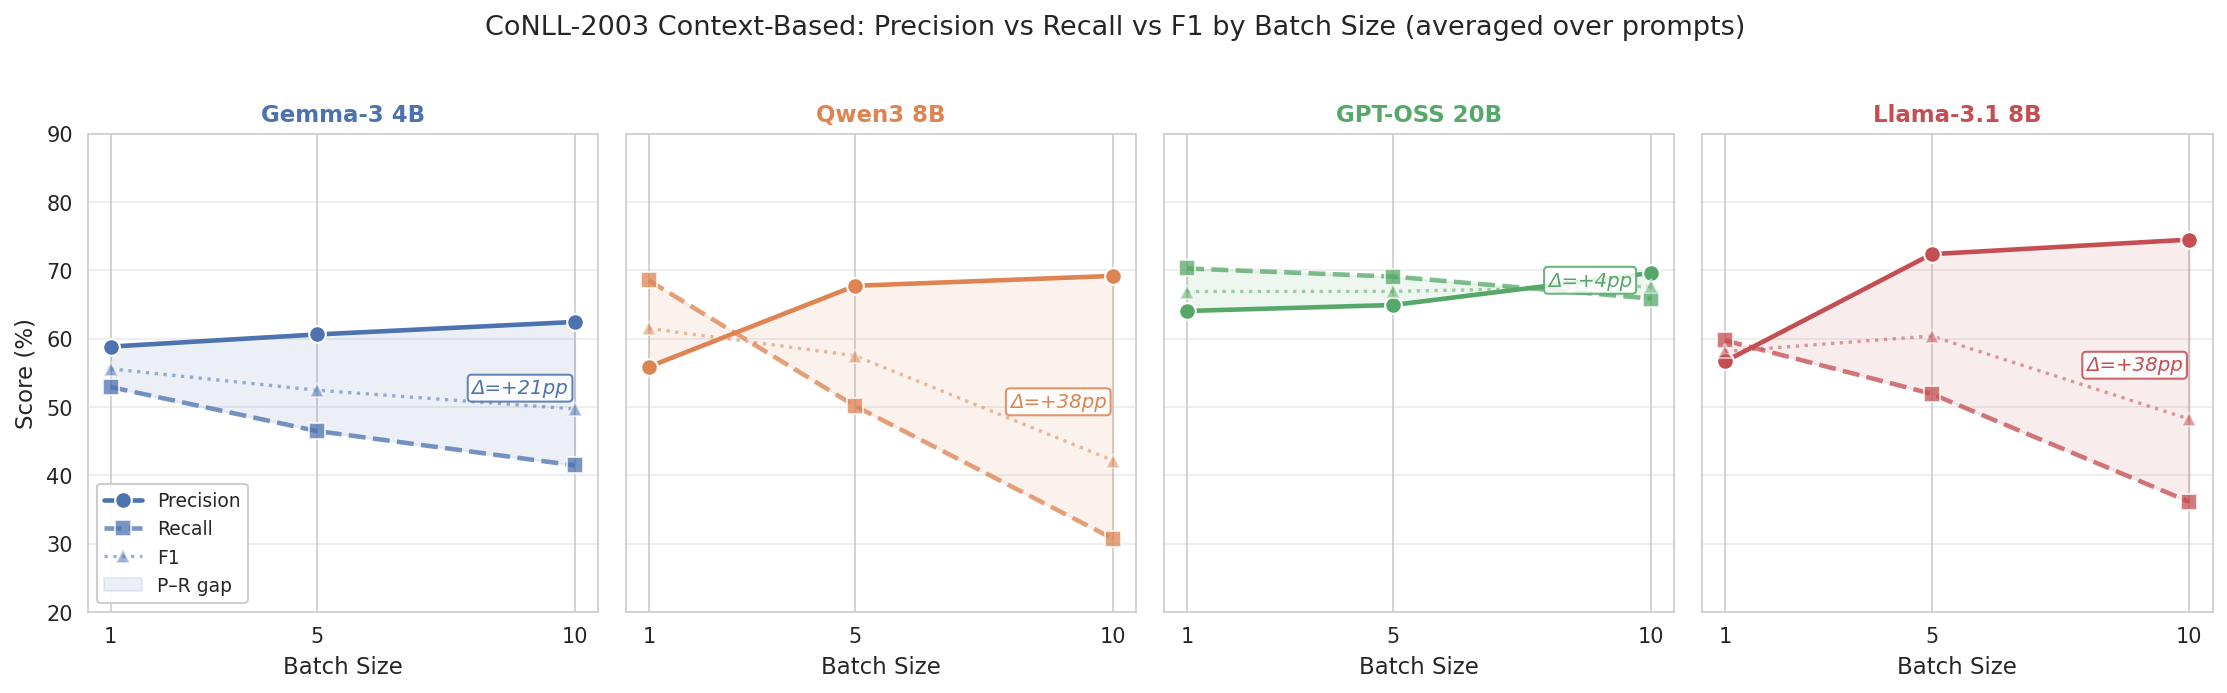

In [13]:
# Precision vs Recall decomposition by batch size.
# Shows that F1 degradation at larger batch sizes is driven by recall collapse, not precision loss.
# GPT-OSS 20B is the exception: near-balanced P/R at every batch size.

stable_bs = [1, 5, 10]

fig, axes = plt.subplots(1, len(ctx_models), figsize=(15, 4.5), sharey=True)

for ax, model in zip(axes, ctx_models):
    color = MODEL_COLORS.get(model, 'gray')
    prec_vals, rec_vals, f1_vals = [], [], []
    for bs in stable_bs:
        sub = ctx_exact[(ctx_exact['batch_size'] == bs) & (ctx_exact['model_short'] == model)]
        prec_vals.append(sub['precision_pct'].mean())
        rec_vals.append(sub['recall_pct'].mean())
        f1_vals.append(sub['main_f1_pct'].mean())

    ax.plot(stable_bs, prec_vals, marker='o', linewidth=2.2, linestyle='-',
            color=color, label='Precision', markersize=8, markeredgecolor='white')
    ax.plot(stable_bs, rec_vals, marker='s', linewidth=2.2, linestyle='--',
            color=color, label='Recall', markersize=8, markeredgecolor='white', alpha=0.75)
    ax.plot(stable_bs, f1_vals, marker='^', linewidth=1.6, linestyle=':',
            color=color, label='F1', markersize=7, markeredgecolor='white', alpha=0.55)

    # Shade the gap between precision and recall
    ax.fill_between(stable_bs, prec_vals, rec_vals,
                    alpha=0.10, color=color,
                    label='P–R gap')

    # Annotate P-R gap at BS=10
    gap = prec_vals[-1] - rec_vals[-1]
    mid_y = (prec_vals[-1] + rec_vals[-1]) / 2
    ax.annotate(f'Δ={gap:+.0f}pp', xy=(10, mid_y),
                xytext=(8.0, mid_y), fontsize=9.5,
                color=color, fontstyle='italic',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=color, alpha=0.85))

    ax.set_title(model, fontweight='bold', color=MODEL_COLORS.get(model, 'black'), fontsize=11)
    ax.set_xticks(stable_bs)
    ax.set_xticklabels(['1', '5', '10'])
    ax.set_xlabel('Batch Size')
    if ax is axes[0]:
        ax.set_ylabel('Score (%)')
    ax.set_ylim(20, 90)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

axes[0].legend(loc='lower left', fontsize=9, framealpha=0.95)

plt.suptitle(
    'CoNLL-2003 Context-Based: Precision vs Recall vs F1 by Batch Size (averaged over prompts)',
    fontsize=13, y=1.02
)
plt.tight_layout()
save_fig(fig, 'conll_ctx_precision_recall_by_bs')


Saved: conll_ctx_f1_vs_throughput.png


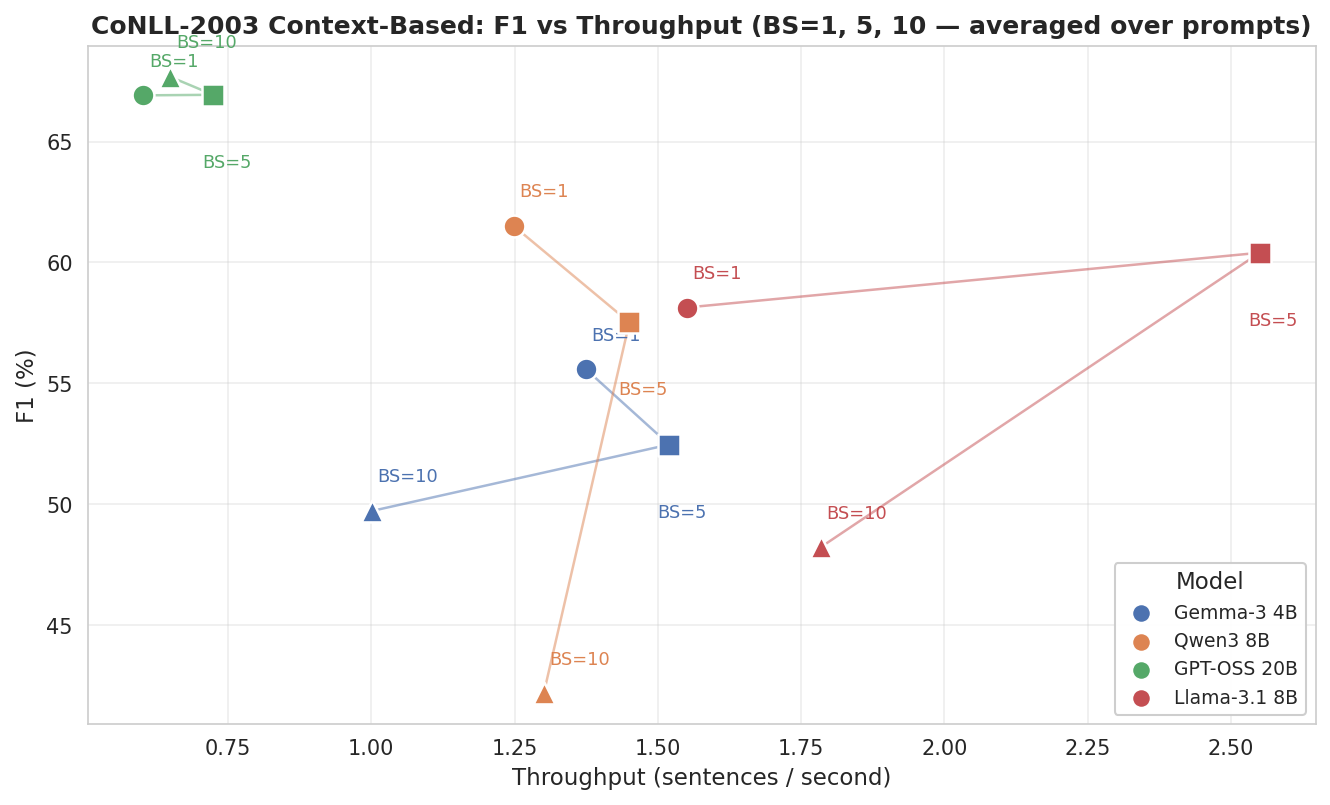

In [14]:
# F1 vs throughput scatter: each point is one (model, batch_size) pair.
# Reveals the Pareto-optimal operating point (BS=5 for most models).
# Throughput = SAMPLE_SIZE / (elapsed_minute_avg * 60) sentences per second.

SAMPLE_SIZE = 250
stable_bs = [1, 5, 10]
markers = {1: 'o', 5: 's', 10: '^'}

fig, ax = plt.subplots(figsize=(9, 5.5))

for model in ctx_models:
    color = MODEL_COLORS.get(model, 'gray')
    xs, ys, labels = [], [], []
    for bs in stable_bs:
        sub = ctx_exact[(ctx_exact['batch_size'] == bs) & (ctx_exact['model_short'] == model)]
        if 'elapsed_minute_avg' not in sub.columns or sub['elapsed_minute_avg'].isna().all():
            continue
        t = sub['elapsed_minute_avg'].mean()
        if t <= 0 or np.isnan(t):
            continue
        thr = SAMPLE_SIZE / (t * 60.0)
        f1 = sub['main_f1_pct'].mean()
        xs.append(thr)
        ys.append(f1)
        labels.append(bs)

    if not xs:
        continue

    # Connect BS points with a thin line per model
    ax.plot(xs, ys, color=color, linewidth=1.2, alpha=0.5, zorder=1)

    for x, y, bs in zip(xs, ys, labels):
        ax.scatter(x, y, color=color, marker=markers[bs], s=110,
                   edgecolors='white', linewidths=1.2, zorder=3)
        # Label with BS number, offset to avoid overlap
        offset = (0.01, 1.2) if bs != 5 else (-0.02, -3.0)
        ax.annotate(f'BS={bs}', xy=(x, y),
                    xytext=(x + offset[0], y + offset[1]),
                    fontsize=8.5, color=color, ha='left')

    # Model legend patch
    ax.scatter([], [], color=color, marker='o', s=80, label=model,
               edgecolors='white', linewidths=1)

ax.set_xlabel('Throughput (sentences / second)', fontsize=11)
ax.set_ylabel('F1 (%)', fontsize=11)
ax.set_title(
    'CoNLL-2003 Context-Based: F1 vs Throughput (BS=1, 5, 10 — averaged over prompts)',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Model', loc='lower right', framealpha=0.95, fontsize=9)
ax.yaxis.grid(True, alpha=0.35)
ax.xaxis.grid(True, alpha=0.35)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig(fig, 'conll_ctx_f1_vs_throughput')


## 3. CoNLL-2003: Constrained Generation Approach

The constrained generation approach uses logits processors to restrict the model's output vocabulary at each decoding step, ensuring that generated spans are substrings of the source document. We compare two processor variants — *whole-sequence* and *token-aware* — against an unconstrained baseline.


In [15]:
cg = load_cg([
    BASE / 'CoNLL/Constrained-Gen/Csv' / f'hf_all_configs_eval_{bs}_BS_conll2003.csv'
    for bs in [1, 5, 10, 64]
])
print(f"Constrained-gen rows: {len(cg)}")
print("Models:", sorted(cg['model_short'].unique()))
print("Configs:", sorted(cg['config'].unique()))
print("Batch sizes:", sorted(cg['batch_size'].unique()))
cg_models = ['Gemma-3 4B', 'Qwen3 8B', 'Llama-3.1 8B']


Constrained-gen rows: 72
Models: ['Gemma-3 4B', 'Llama-3.1 8B', 'Qwen3 8B']
Configs: ['Token-Aware', 'Unconstrained', 'Whole-Sequence']
Batch sizes: [1, 5, 10, 64]


Saved: conll_cg_wrong_text_rate.png


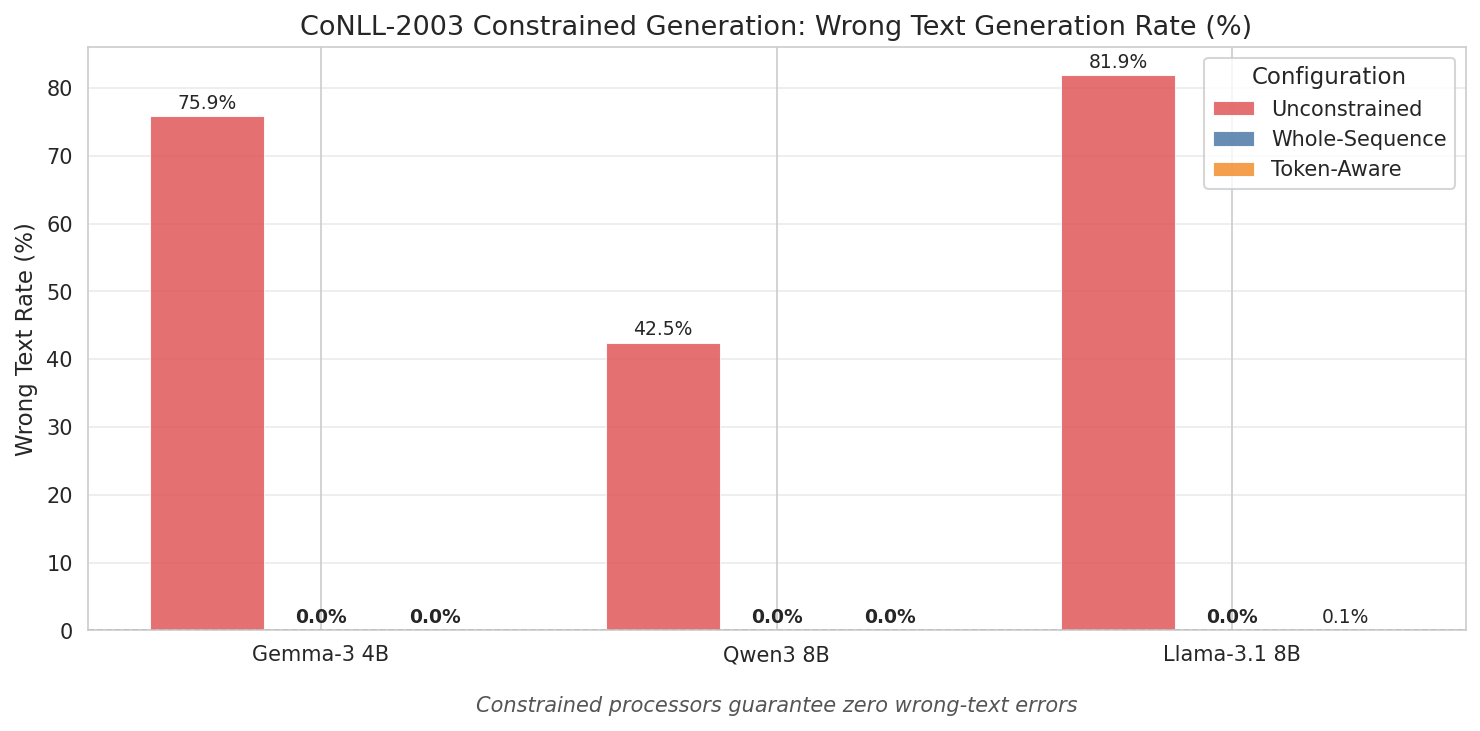

In [16]:
def make_wrong_text_plot(df, models, title, figname, col='wrong_text_rate_pct'):
    df_greedy = df[df.get('do_sample', pd.Series([False]*len(df))).astype(str).str.lower().isin(['false', '0'])] if 'do_sample' in df.columns else df
    if len(df_greedy) == 0:
        df_greedy = df

    configs = ['Unconstrained', 'Whole-Sequence', 'Token-Aware']
    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, cfg in enumerate(configs):
        vals = []
        for model in models:
            sub = df_greedy[(df_greedy['model_short'] == model) & (df_greedy['config'] == cfg)]
            vals.append(sub[col].mean() if (col in sub.columns and len(sub) > 0) else np.nan)
        bars = ax.bar(x + i * width, vals, width, label=cfg,
                      color=PROC_COLORS[cfg], alpha=0.85, edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                label_txt = f'{val:.1f}%'
                y_pos = bar.get_height() + 0.5
                ax.text(bar.get_x() + bar.get_width() / 2, y_pos, label_txt,
                        ha='center', va='bottom', fontsize=9, fontweight='bold' if val == 0 else 'normal')

    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5, linestyle='--')
    ax.set_xticks(x + width)
    ax.set_xticklabels(models)
    ax.set_ylabel(col.replace('_', ' ').title().replace('Pct', '(%)'))
    ax.set_title(title, fontsize=13)
    ax.legend(title='Configuration')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    ax.annotate('Constrained processors guarantee zero wrong-text errors',
                xy=(0.5, -0.14), xycoords='axes fraction', ha='center',
                fontsize=10, style='italic', color='#555555')
    plt.tight_layout()
    save_fig(fig, figname)

make_wrong_text_plot(
    cg, cg_models,
    'CoNLL-2003 Constrained Generation: Wrong Text Generation Rate (%)',
    'conll_cg_wrong_text_rate', col='wrong_text_rate_pct'
)


Saved: conll_cg_unaligned_entity_rate.png


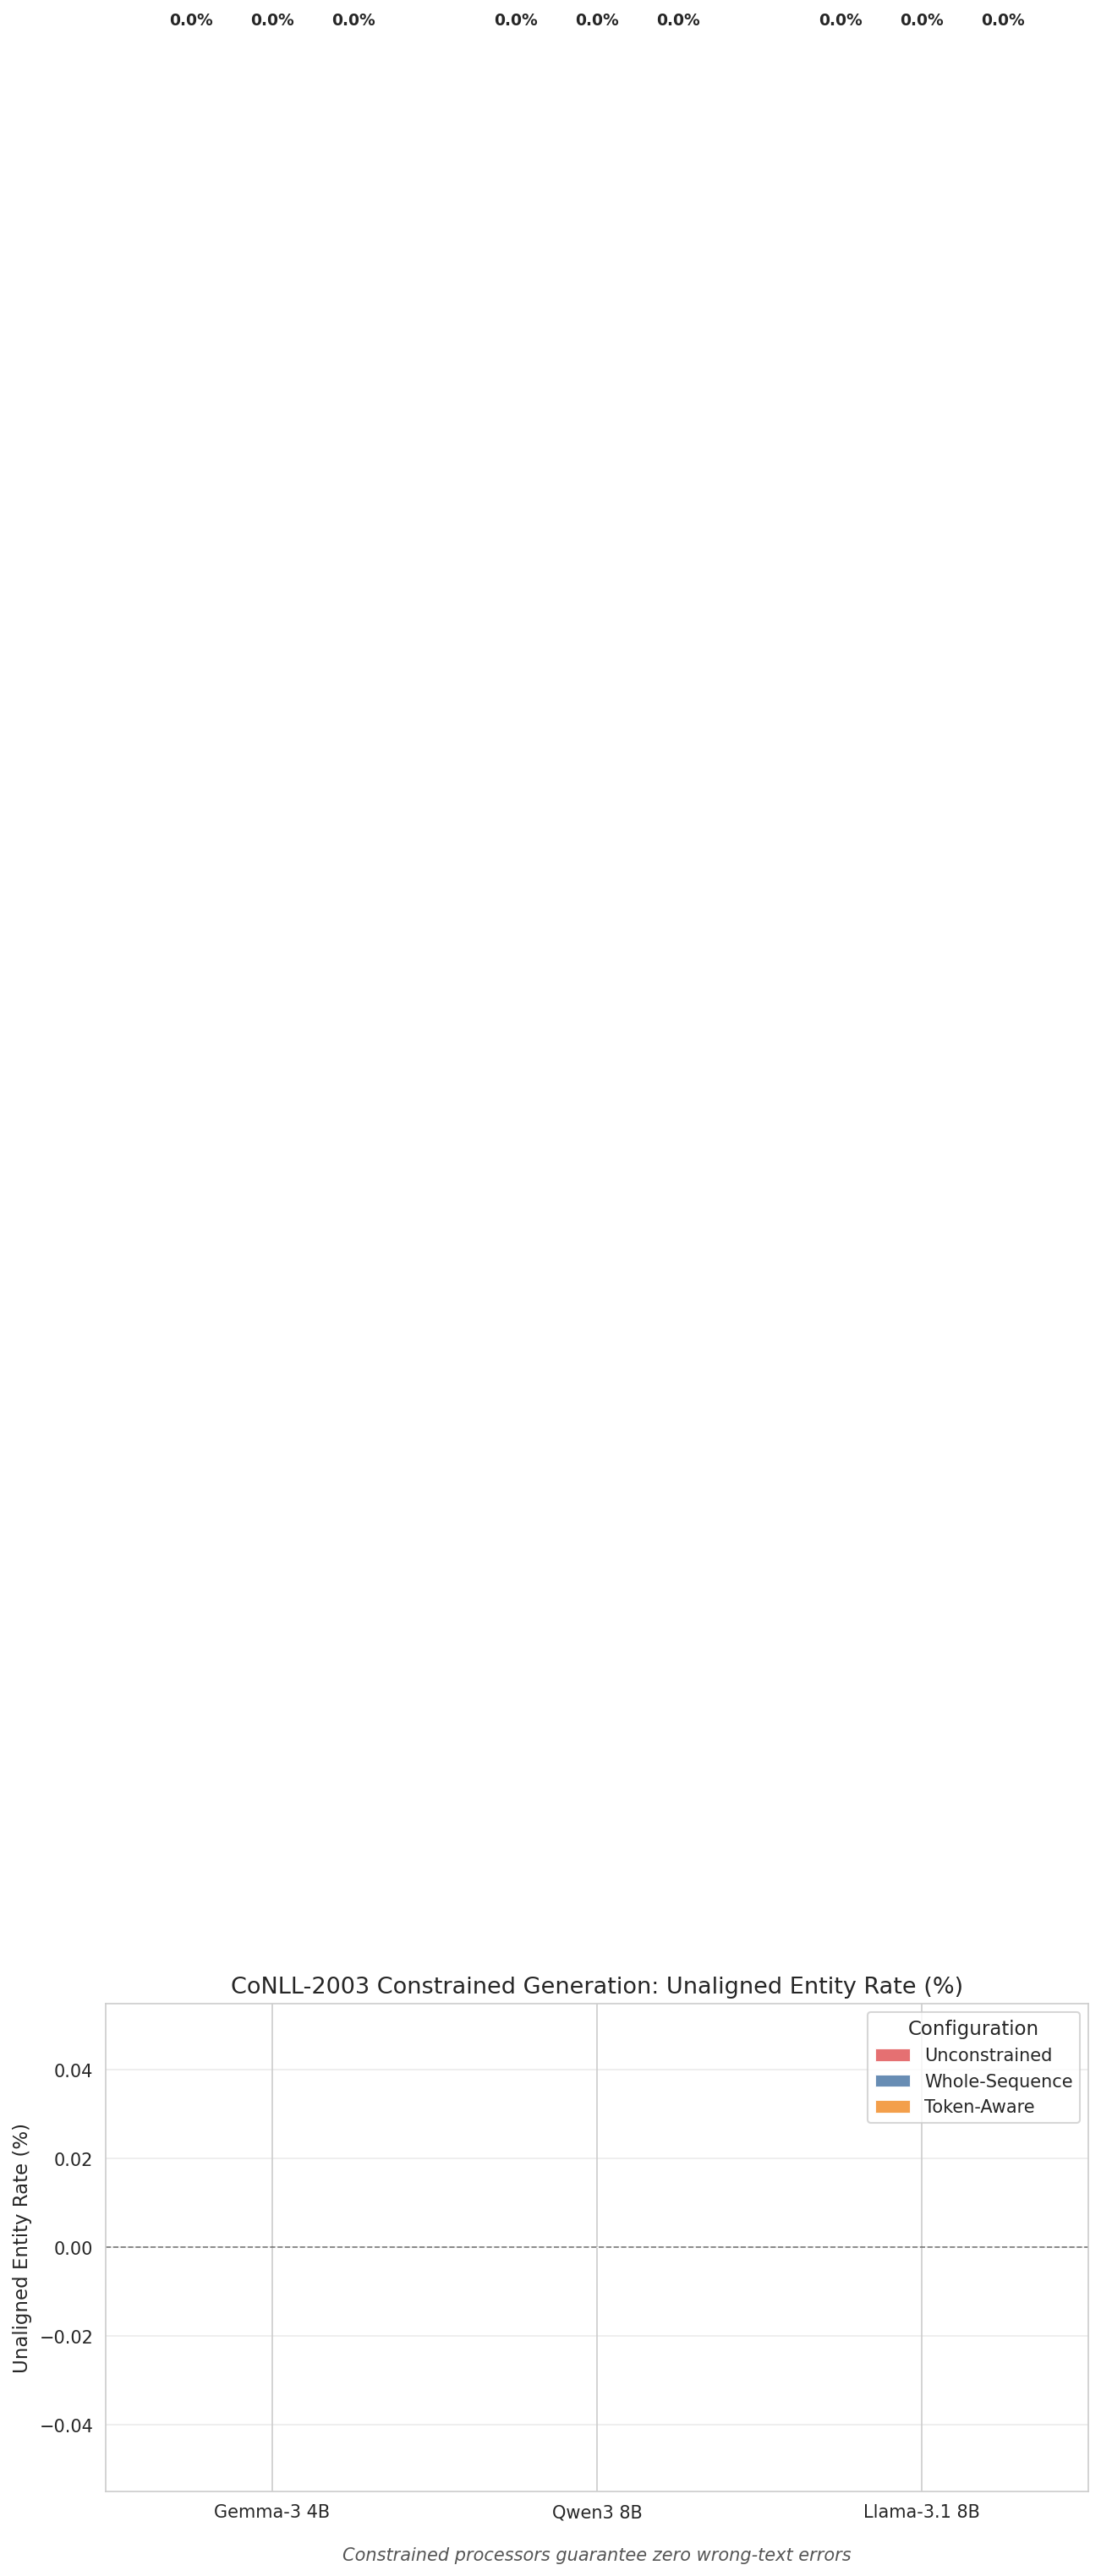

In [17]:
make_wrong_text_plot(
    cg, cg_models,
    'CoNLL-2003 Constrained Generation: Unaligned Entity Rate (%)',
    'conll_cg_unaligned_entity_rate', col='unaligned_entity_rate_pct'
)


Saved: conll_cg_f1_comparison_bs1.png


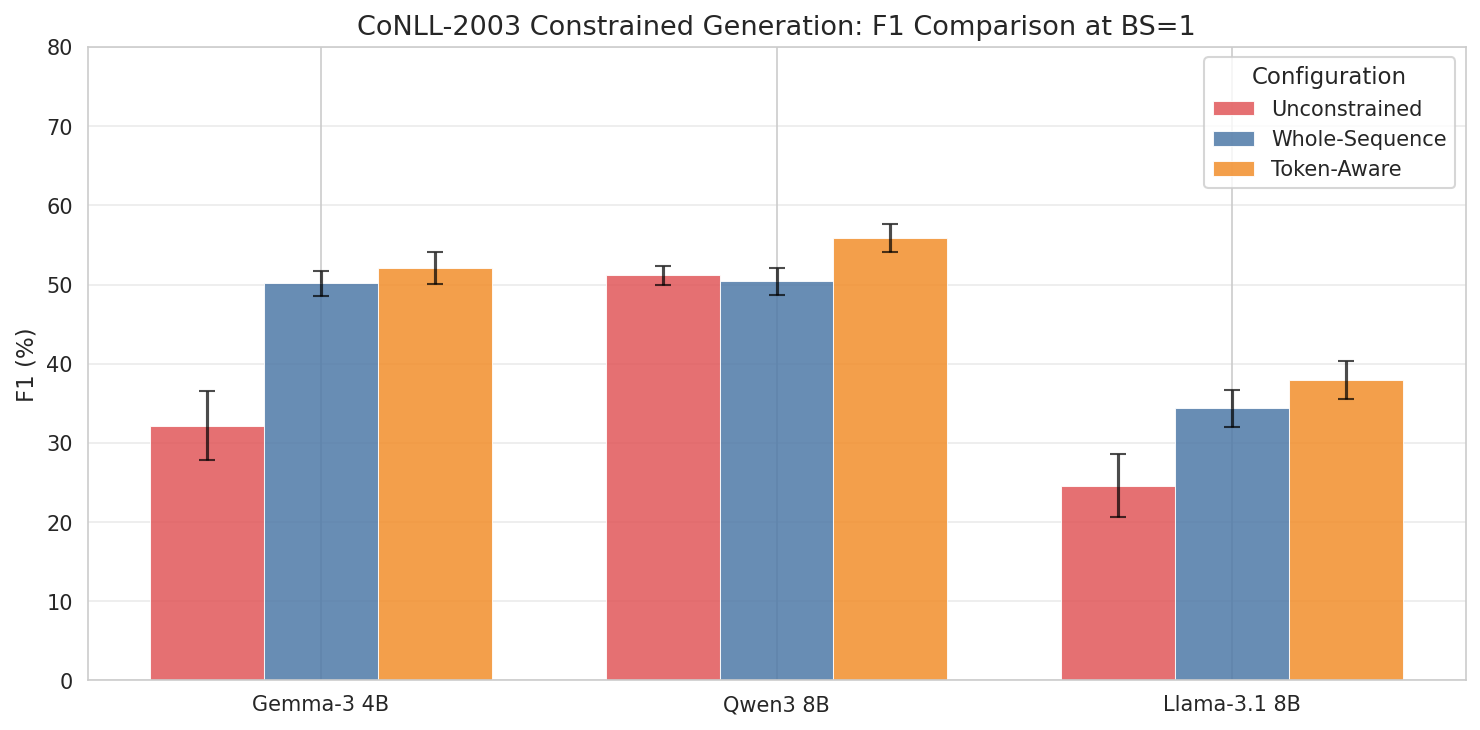

In [18]:
def make_f1_comparison_plot(df, models, y_label, title, figname, ylim=80):
    df_bs1 = df[df['batch_size'] == 1].copy()
    df_greedy = df_bs1
    if 'do_sample' in df_bs1.columns:
        df_greedy = df_bs1[df_bs1['do_sample'].astype(str).str.lower().isin(['false', '0'])]
    if len(df_greedy) == 0:
        df_greedy = df_bs1

    configs = ['Unconstrained', 'Whole-Sequence', 'Token-Aware']
    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, cfg in enumerate(configs):
        vals, errs = [], []
        for model in models:
            sub = df_greedy[(df_greedy['model_short'] == model) & (df_greedy['config'] == cfg)]
            vals.append(sub['main_f1_pct'].mean() if len(sub) > 0 else np.nan)
            errs.append(safe_err(sub['main_f1_std_pct'].mean()) if len(sub) > 0 else 0.0)
        ax.bar(x + i * width, vals, width, label=cfg, color=PROC_COLORS[cfg], alpha=0.85,
               yerr=errs, capsize=4, error_kw={'alpha': 0.7}, edgecolor='white', linewidth=0.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(models)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, ylim)
    ax.set_title(title, fontsize=13)
    ax.legend(title='Configuration')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    save_fig(fig, figname)

make_f1_comparison_plot(
    cg, cg_models,
    'F1 (%)',
    'CoNLL-2003 Constrained Generation: F1 Comparison at BS=1',
    'conll_cg_f1_comparison_bs1'
)


Saved: conll_cg_processor_comparison.png


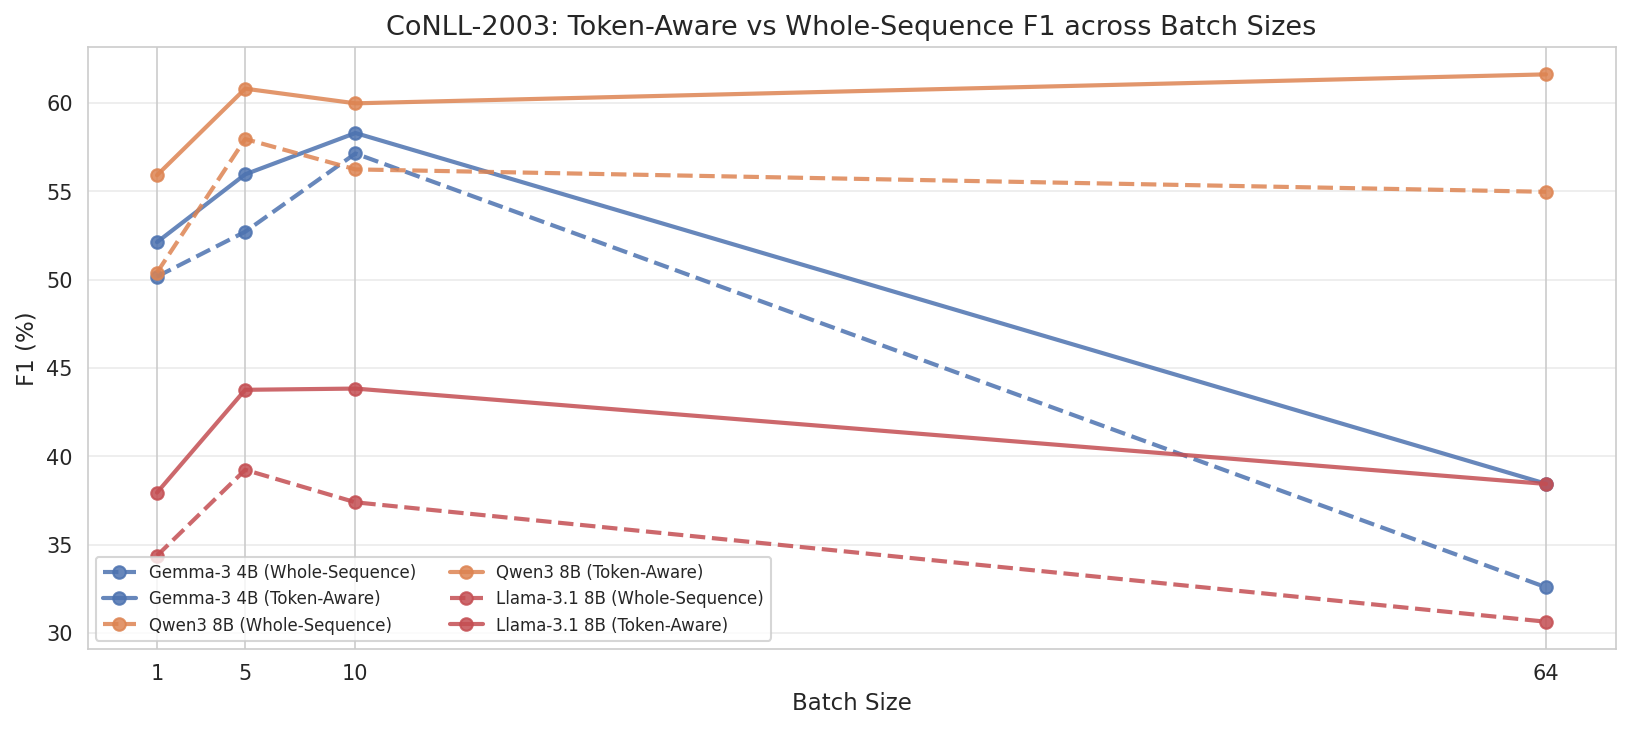

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
cg_constrained = cg[cg['config'].isin(['Whole-Sequence', 'Token-Aware'])].copy()
if 'do_sample' in cg_constrained.columns:
    cg_constrained = cg_constrained[cg_constrained['do_sample'].astype(str).str.lower().isin(['false', '0'])]

line_styles = {'Whole-Sequence': '--', 'Token-Aware': '-'}

for model in cg_models:
    for cfg in ['Whole-Sequence', 'Token-Aware']:
        sub = cg_constrained[(cg_constrained['model_short'] == model) & (cg_constrained['config'] == cfg)]
        agg = sub.groupby('batch_size').agg(
            f1_mean=('main_f1_pct', 'mean'),
            f1_std=('main_f1_std_pct', 'mean')
        ).reindex(batch_sizes)
        ax.plot(batch_sizes, agg['f1_mean'].values,
                marker='o', linestyle=line_styles[cfg],
                color=MODEL_COLORS.get(model, 'gray'),
                linewidth=2, label=f'{model} ({cfg})', alpha=0.85)

ax.set_xticks(batch_sizes)
ax.set_xticklabels(['1', '5', '10', '64'])
ax.set_xlabel('Batch Size')
ax.set_ylabel('F1 (%)')
ax.set_title('CoNLL-2003: Token-Aware vs Whole-Sequence F1 across Batch Sizes', fontsize=13)
ax.legend(fontsize=8, ncol=2)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig(fig, 'conll_cg_processor_comparison')


Saved: conll_cg_consistency_vs_batch_size.png


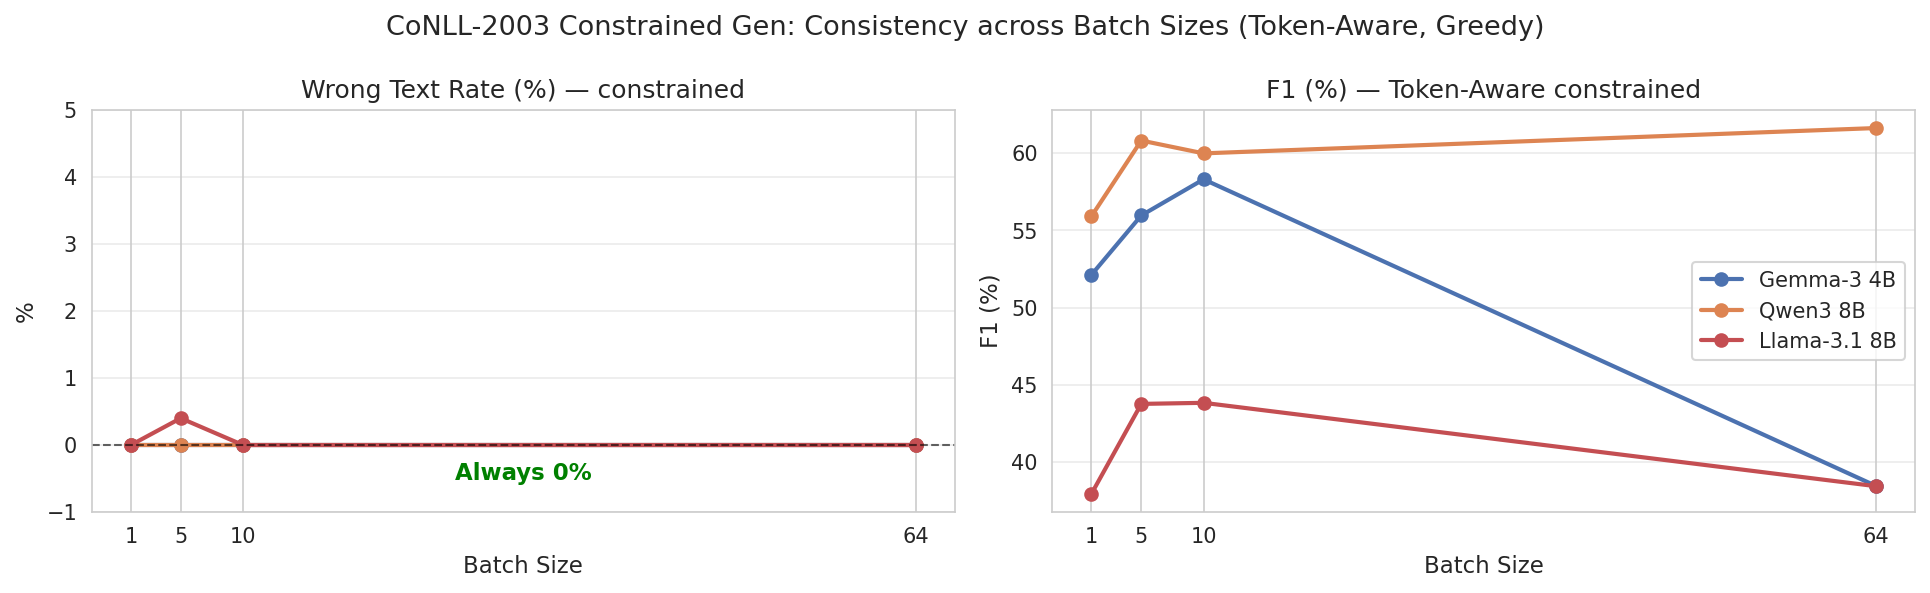

In [20]:
cg_constrained2 = cg[cg['config'].isin(['Whole-Sequence', 'Token-Aware'])].copy()
if 'do_sample' in cg_constrained2.columns:
    cg_constrained2 = cg_constrained2[cg_constrained2['do_sample'].astype(str).str.lower().isin(['false', '0'])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for model in cg_models:
    for cfg in ['Token-Aware']:
        sub = cg_constrained2[(cg_constrained2['model_short'] == model) & (cg_constrained2['config'] == cfg)]
        agg_wt = sub.groupby('batch_size')['wrong_text_rate_pct'].mean().reindex(batch_sizes)
        agg_f1 = sub.groupby('batch_size')['main_f1_pct'].mean().reindex(batch_sizes)
        color = MODEL_COLORS.get(model, 'gray')
        ax1.plot(batch_sizes, agg_wt.values, marker='o', color=color, linewidth=2, label=model)
        ax2.plot(batch_sizes, agg_f1.values, marker='o', color=color, linewidth=2, label=model)

ax1.set_title('Wrong Text Rate (%) — constrained', fontsize=12)
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('%')
ax1.set_xticks(batch_sizes)
ax1.set_xticklabels(['1', '5', '10', '64'])
ax1.set_ylim(-1, 5)
ax1.yaxis.grid(True, alpha=0.4)
ax1.set_axisbelow(True)
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax1.annotate('Always 0%', xy=(0.5, 0.08), xycoords='axes fraction', ha='center',
             fontsize=11, color='green', fontweight='bold')

ax2.set_title('F1 (%) — Token-Aware constrained', fontsize=12)
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('F1 (%)')
ax2.set_xticks(batch_sizes)
ax2.set_xticklabels(['1', '5', '10', '64'])
ax2.legend()
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle('CoNLL-2003 Constrained Gen: Consistency across Batch Sizes (Token-Aware, Greedy)', fontsize=13)
plt.tight_layout()
save_fig(fig, 'conll_cg_consistency_vs_batch_size')


Saved: conll_cg_runtime.png


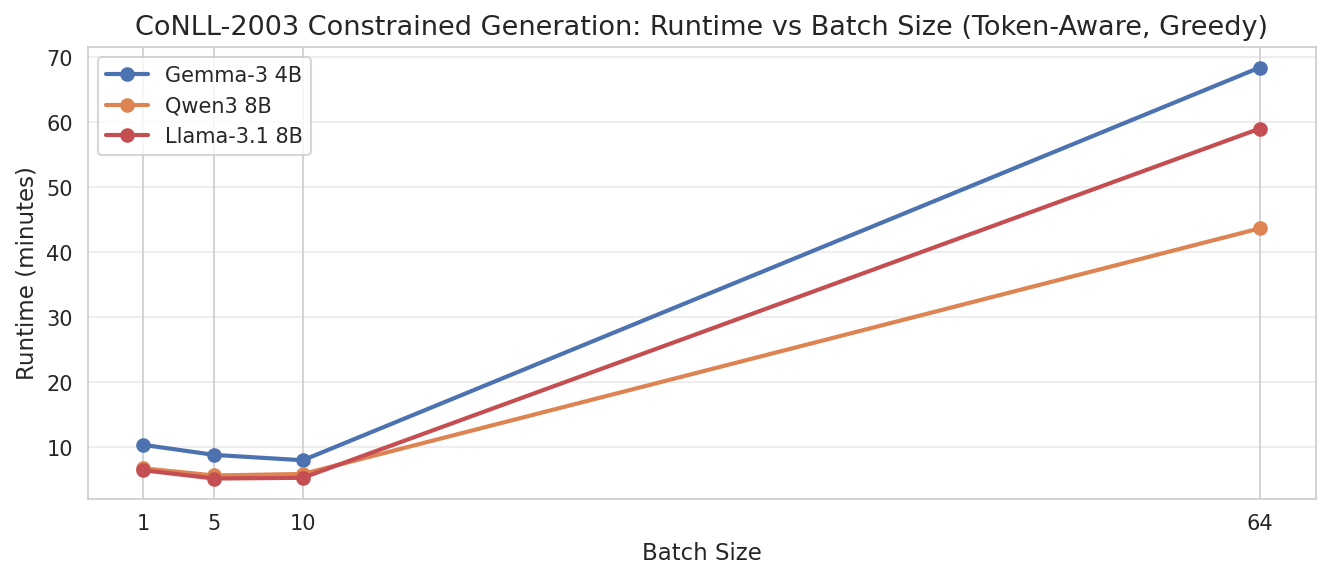

In [21]:
cg_ta = cg[(cg['config'] == 'Token-Aware')].copy()
if 'do_sample' in cg_ta.columns:
    cg_ta = cg_ta[cg_ta['do_sample'].astype(str).str.lower().isin(['false', '0'])]

fig, ax = plt.subplots(figsize=(9, 4))
for model in cg_models:
    sub = cg_ta[cg_ta['model_short'] == model]
    if 'elapsed_minute_avg' in sub.columns:
        agg = sub.groupby('batch_size')['elapsed_minute_avg'].mean().reindex(batch_sizes)
        ax.plot(batch_sizes, agg.values, marker='o', linewidth=2,
                color=MODEL_COLORS.get(model, 'gray'), label=model)

ax.set_xticks(batch_sizes)
ax.set_xticklabels(['1', '5', '10', '64'])
ax.set_xlabel('Batch Size')
ax.set_ylabel('Runtime (minutes)')
ax.set_title('CoNLL-2003 Constrained Generation: Runtime vs Batch Size (Token-Aware, Greedy)', fontsize=13)
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig(fig, 'conll_cg_runtime')


## 4. CoNLL-2003: Cross-Approach Comparison

We compare the best-performing configuration for each approach: context-based with fuzzy matching at BS=5, and constrained generation (token-aware, greedy) at BS=5. GPT-OSS 20B appears only in the context-based results since it was not evaluated in the HuggingFace constrained-gen pipeline.


Saved: conll_cross_approach_f1.png


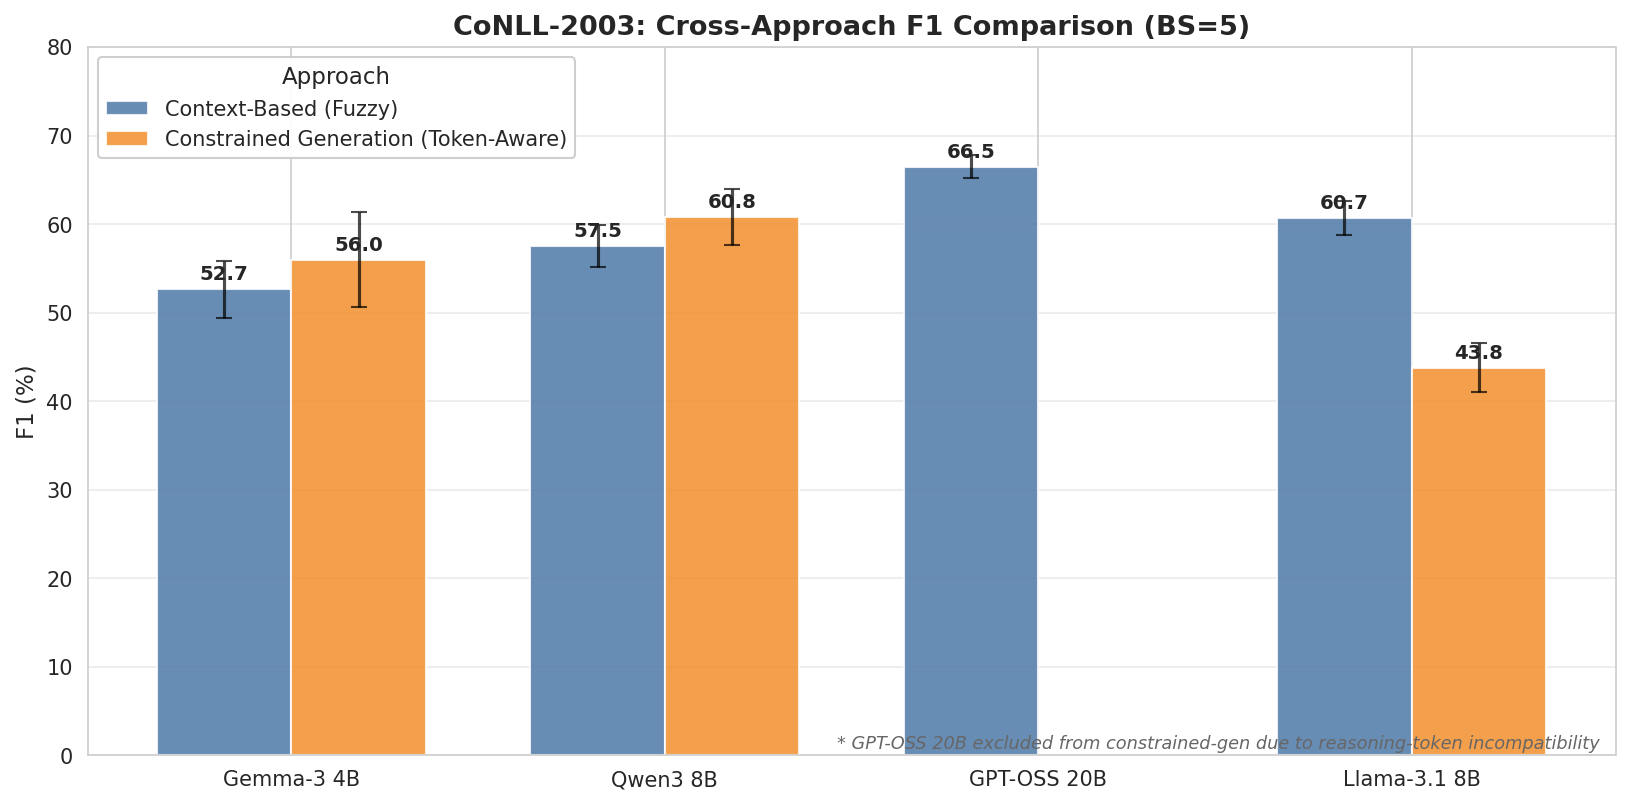

In [22]:
# Cross-approach comparison at the best operating point for each approach.
# Context-based: BS=5 with fuzzy matching (averaged over all 3 prompts).
# Constrained-gen: BS=5, token-aware processor, greedy decoding.
# GPT-OSS 20B is omitted from constrained-gen (no logits processor support in the OpenAI-compatible pipeline).

# Context-based: take fuzzy matching at BS=5, averaged across prompts.
ctx_bs5 = ctx_fuzzy[ctx_fuzzy['batch_size'] == 5]
ctx_best = ctx_bs5.groupby('model_short').agg(
    f1=('main_f1_pct', 'mean'),
    f1_std=('main_f1_pct', 'std'),
).reset_index()
ctx_best['approach'] = 'Context-Based (Fuzzy)'

# Constrained-gen: token-aware, greedy, BS=5
cg_bs5 = cg[(cg['batch_size'] == 5) & (cg['config'] == 'Token-Aware')].copy()
if 'do_sample' in cg_bs5.columns:
    cg_bs5 = cg_bs5[cg_bs5['do_sample'].astype(str).str.lower().isin(['false', '0'])]
cg_best = cg_bs5.groupby('model_short').agg(
    f1=('main_f1_pct', 'mean'),
    f1_std=('main_f1_std_pct', 'mean'),
).reset_index()
cg_best['approach'] = 'Constrained Generation (Token-Aware)'

combined = pd.concat([ctx_best, cg_best], ignore_index=True)
all_models = ['Gemma-3 4B', 'Qwen3 8B', 'GPT-OSS 20B', 'Llama-3.1 8B']

x = np.arange(len(all_models))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))
colors_approach = {'Context-Based (Fuzzy)': '#4E79A7',
                   'Constrained Generation (Token-Aware)': '#F28E2B'}

for i, approach in enumerate(['Context-Based (Fuzzy)', 'Constrained Generation (Token-Aware)']):
    vals, errs = [], []
    for model in all_models:
        row = combined[(combined['model_short'] == model) & (combined['approach'] == approach)]
        if len(row) > 0:
            vals.append(row['f1'].values[0])
            errs.append(safe_err(row['f1_std'].values[0]))
        else:
            vals.append(np.nan)
            errs.append(0)
    bars = ax.bar(x + i * width, vals, width, label=approach,
                  color=colors_approach[approach], alpha=0.85, edgecolor='white',
                  yerr=errs, capsize=4, error_kw={'alpha': 0.7})
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(all_models, fontsize=10)
ax.set_ylabel('F1 (%)')
ax.set_ylim(0, max(combined['f1'].max() + 10, 80))
ax.set_title('CoNLL-2003: Cross-Approach F1 Comparison (BS=5)',
             fontsize=13, fontweight='bold')
ax.legend(title='Approach', loc='upper left', framealpha=0.95)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.annotate('* GPT-OSS 20B excluded from constrained-gen due to reasoning-token incompatibility',
            xy=(0.99, 0.01), xycoords='axes fraction', ha='right',
            fontsize=8.5, style='italic', color='#666')
plt.tight_layout()
save_fig(fig, 'conll_cross_approach_f1')


In [23]:
# LaTeX-ready summary table for the thesis: best F1 per model and approach on CoNLL-2003.
# Includes mean and standard deviation across batch sizes / prompts / iterations.

print("=== CoNLL-2003 Best F1 Summary Table ===\n")

rows = []
for model in all_models:
    ctx_row = combined[(combined['model_short'] == model) & (combined['approach'] == 'Context-Based (Fuzzy)')]
    cg_row = combined[(combined['model_short'] == model) & (combined['approach'] == 'Constrained Generation (Token-Aware)')]

    ctx_f1 = f"{ctx_row['f1'].values[0]:.1f} ± {safe_err(ctx_row['f1_std'].values[0]):.1f}" if len(ctx_row) > 0 else '—'
    cg_f1 = f"{cg_row['f1'].values[0]:.1f} ± {safe_err(cg_row['f1_std'].values[0]):.1f}" if len(cg_row) > 0 else '—'

    rows.append({'Model': model,
                 'Context-Based Fuzzy F1 (%)': ctx_f1,
                 'Constrained-Gen Token-Aware F1 (%)': cg_f1})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# LaTeX output
print("\n=== LaTeX table source (paste into the thesis) ===\n")
print(r"\begin{table}[ht]")
print(r"\centering")
print(r"\begin{tabular}{lcc}")
print(r"\toprule")
print(r"\textbf{Model} & \textbf{Context-Based (Fuzzy)} & \textbf{Constrained Gen.} \\")
print(r"               & \textbf{F1 (\%)}                & \textbf{F1 (\%)}            \\")
print(r"\midrule")
for _, r in df_summary.iterrows():
    ctx_str = r['Context-Based Fuzzy F1 (%)'].replace('±', r'$\pm$')
    cg_str = r['Constrained-Gen Token-Aware F1 (%)'].replace('±', r'$\pm$')
    if cg_str == '—':
        cg_str = r'\multicolumn{1}{c}{—}'
    print(f"{r['Model']} & {ctx_str} & {cg_str} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\caption{Best F1 score per model and approach on CoNLL-2003 at batch size~5. " +
      r"Context-based uses fuzzy matching averaged across the three prompt variants; " +
      r"constrained generation uses the token-aware processor with greedy decoding. " +
      r"GPT-OSS~20B is excluded from constrained generation due to reasoning-token incompatibility.}")
print(r"\label{tab:conll_cross_approach}")
print(r"\end{table}")

df_summary


=== CoNLL-2003 Best F1 Summary Table ===

       Model Context-Based Fuzzy F1 (%) Constrained-Gen Token-Aware F1 (%)
  Gemma-3 4B                 52.7 ± 3.2                         56.0 ± 5.4
    Qwen3 8B                 57.5 ± 2.4                         60.8 ± 3.2
 GPT-OSS 20B                 66.5 ± 1.3                                  —
Llama-3.1 8B                 60.7 ± 1.9                         43.8 ± 2.8

=== LaTeX table source (paste into the thesis) ===

\begin{table}[ht]
\centering
\begin{tabular}{lcc}
\toprule
\textbf{Model} & \textbf{Context-Based (Fuzzy)} & \textbf{Constrained Gen.} \\
               & \textbf{F1 (\%)}                & \textbf{F1 (\%)}            \\
\midrule
Gemma-3 4B & 52.7 $\pm$ 3.2 & 56.0 $\pm$ 5.4 \\
Qwen3 8B & 57.5 $\pm$ 2.4 & 60.8 $\pm$ 3.2 \\
GPT-OSS 20B & 66.5 $\pm$ 1.3 & \multicolumn{1}{c}{—} \\
Llama-3.1 8B & 60.7 $\pm$ 1.9 & 43.8 $\pm$ 2.8 \\
\bottomrule
\end{tabular}
\caption{Best F1 score per model and approach on CoNLL-2003 at batch size~5

,Model,Context-Based Fuzzy F1 (%),Constrained-Gen Token-Aware F1 (%)
0,Gemma-3 4B,52.7 ± 3.2,56.0 ± 5.4
1,Qwen3 8B,57.5 ± 2.4,60.8 ± 3.2
2,GPT-OSS 20B,66.5 ± 1.3,—
3,Llama-3.1 8B,60.7 ± 1.9,43.8 ± 2.8


## 5. ToxicSpans: Toxic Span Detection

ToxicSpans is a character-level span classification task. All experiments use batch size 1. We evaluate the same two approaches and report character-level F1 (char-F1).


In [24]:
ts_ctx_exact = load_ctx(
    [BASE / 'ToxicSpans/Context-Based/Csv/toxic_spans_context.csv'], char_level=True)
ts_ctx_fuzzy = load_ctx(
    [BASE / 'ToxicSpans/Context-Based/Csv/toxic_spans_context_fuzzy.csv'], char_level=True)
ts_cg = load_cg(
    [BASE / 'ToxicSpans/Constrained-Gen/Csv/hf_all_configs_eval_1_BS_toxic_spans.csv'],
    char_level=True)

print(f"ToxicSpans context rows: {len(ts_ctx_exact)}, CG rows: {len(ts_cg)}")
ts_cg_models = [m for m in cg_models if m in ts_cg['model_short'].values]


ToxicSpans context rows: 12, CG rows: 18


Saved: toxic_ctx_char_f1_by_prompt.png


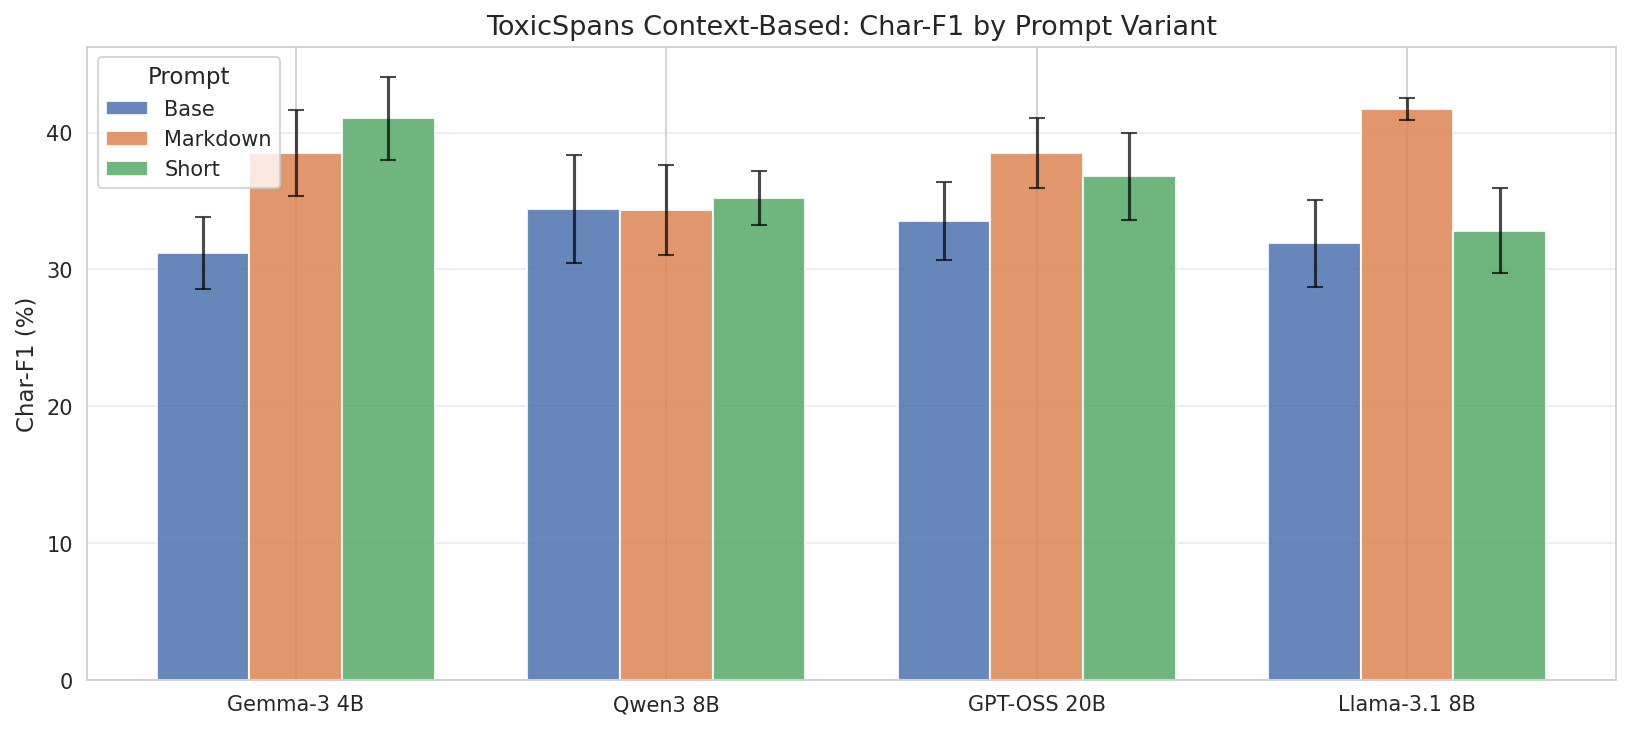

In [25]:
ts_models_ctx = [m for m in ['Gemma-3 4B', 'Qwen3 8B', 'GPT-OSS 20B', 'Llama-3.1 8B']
                 if m in ts_ctx_exact['model_short'].values]
prompts_ts = sorted(ts_ctx_exact['prompt_short'].dropna().unique()) if 'prompt_short' in ts_ctx_exact.columns else ['Base']
x = np.arange(len(ts_models_ctx))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, prompt in enumerate(prompts_ts[:3]):
    sub = ts_ctx_exact[ts_ctx_exact.get('prompt_short', pd.Series()) == prompt] if 'prompt_short' in ts_ctx_exact.columns else ts_ctx_exact
    vals = [sub[sub['model_short'] == m]['main_f1_pct'].mean() if len(sub[sub['model_short'] == m]) > 0 else np.nan
            for m in ts_models_ctx]
    errs = [safe_err(sub[sub['model_short'] == m]['main_f1_std_pct'].mean()) if len(sub[sub['model_short'] == m]) > 0 else 0
            for m in ts_models_ctx]
    ax.bar(x + i * width, vals, width, label=prompt,
           color=list(PROMPT_COLORS.values())[i], alpha=0.85,
           yerr=errs, capsize=4, error_kw={'alpha': 0.7})

ax.set_xticks(x + width)
ax.set_xticklabels(ts_models_ctx)
ax.set_ylabel('Char-F1 (%)')
ax.set_title('ToxicSpans Context-Based: Char-F1 by Prompt Variant', fontsize=13)
ax.legend(title='Prompt')
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig(fig, 'toxic_ctx_char_f1_by_prompt')


Saved: toxic_cg_wrong_text_rate.png


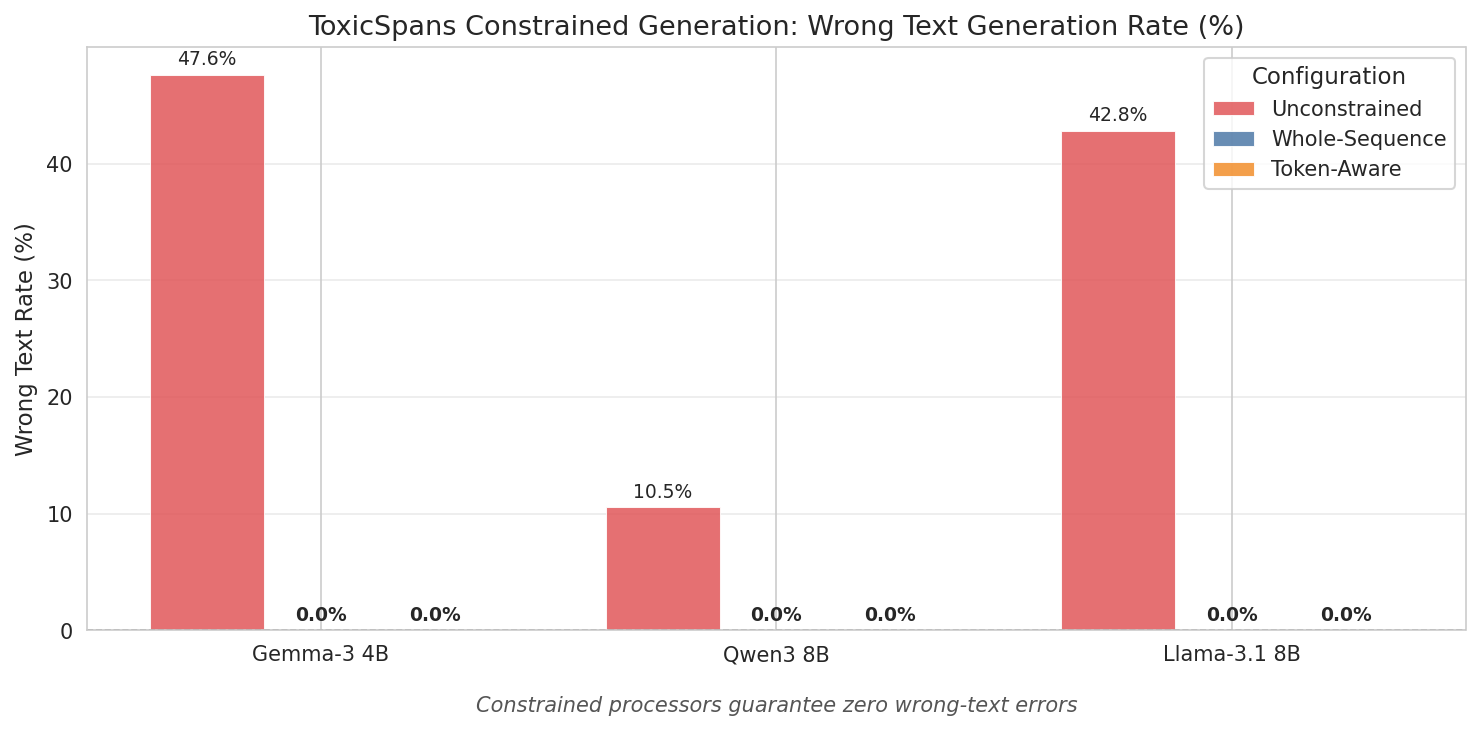

In [26]:
make_wrong_text_plot(
    ts_cg, ts_cg_models,
    'ToxicSpans Constrained Generation: Wrong Text Generation Rate (%)',
    'toxic_cg_wrong_text_rate', col='wrong_text_rate_pct'
)


Saved: toxic_cg_char_f1_comparison.png


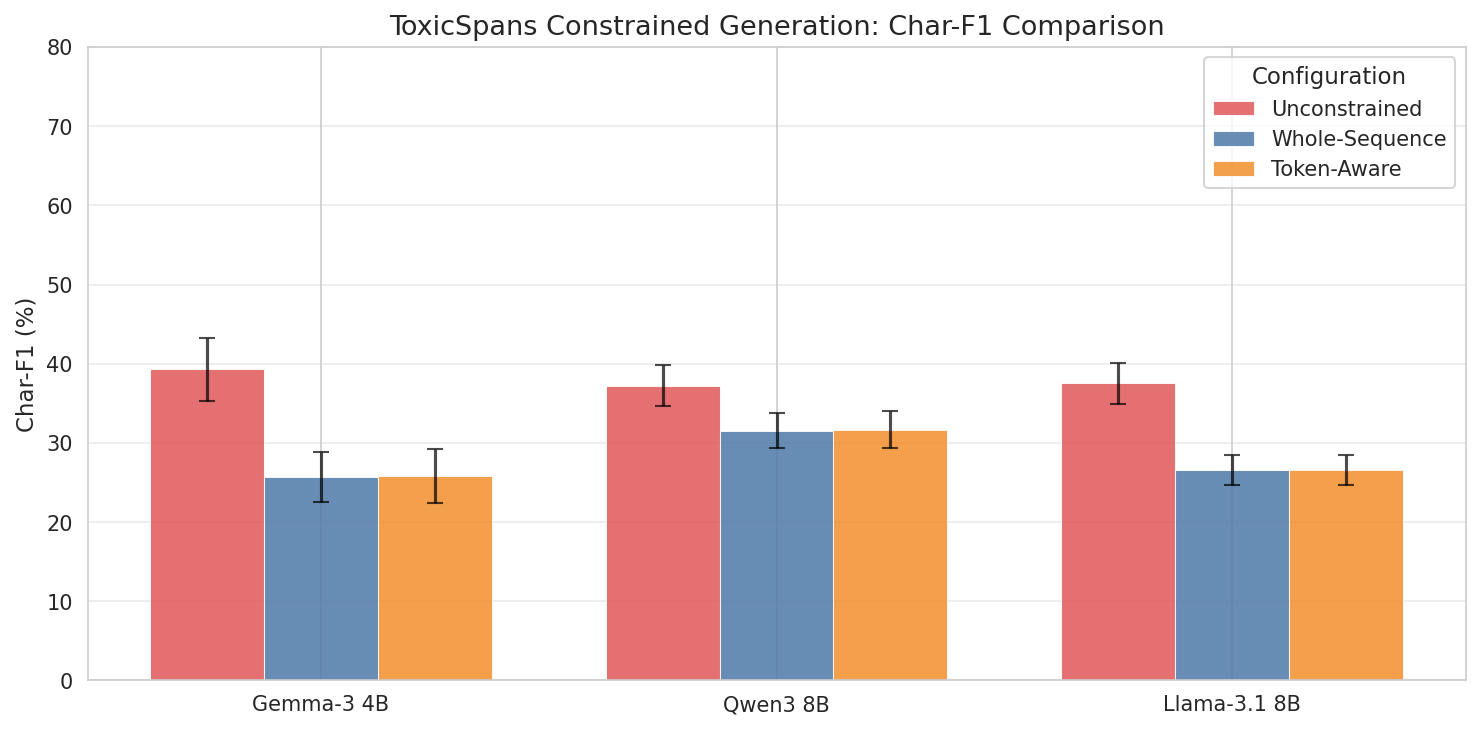

In [27]:
make_f1_comparison_plot(
    ts_cg, ts_cg_models,
    'Char-F1 (%)',
    'ToxicSpans Constrained Generation: Char-F1 Comparison',
    'toxic_cg_char_f1_comparison', ylim=80
)


## 6. LegalQA: Extractive Legal Question Answering

The LegalQAEval dataset contains long legal documents. Spans can be multi-sentence passages, making this the hardest generalization challenge. We report character-level F1. A key anomaly: constrained generation *underperforms* unconstrained for Gemma-3 4B on this dataset — likely because the constrained processor forces character-by-character reproduction of very long legal passages, degrading span boundary precision.


In [28]:
lq_ctx_exact = load_ctx(
    [BASE / 'LegalQAEval/Context-Based/Csv/legalqa_context_1_BATCHSZ.csv'], char_level=True)
lq_ctx_fuzzy = load_ctx(
    [BASE / 'LegalQAEval/Context-Based/Csv/legalqa_context_fuzzy_1_BATCHSZ.csv'], char_level=True)
lq_cg = load_cg(
    [BASE / 'LegalQAEval/Constrained-Gen/Csv/hf_all_configs_eval_1_BS_legalqa.csv'],
    char_level=True)

print(f"LegalQA context rows: {len(lq_ctx_exact)}, CG rows: {len(lq_cg)}")
lq_cg_models = [m for m in cg_models if m in lq_cg['model_short'].values]


LegalQA context rows: 12, CG rows: 18


Saved: legalqa_ctx_char_f1_by_prompt.png


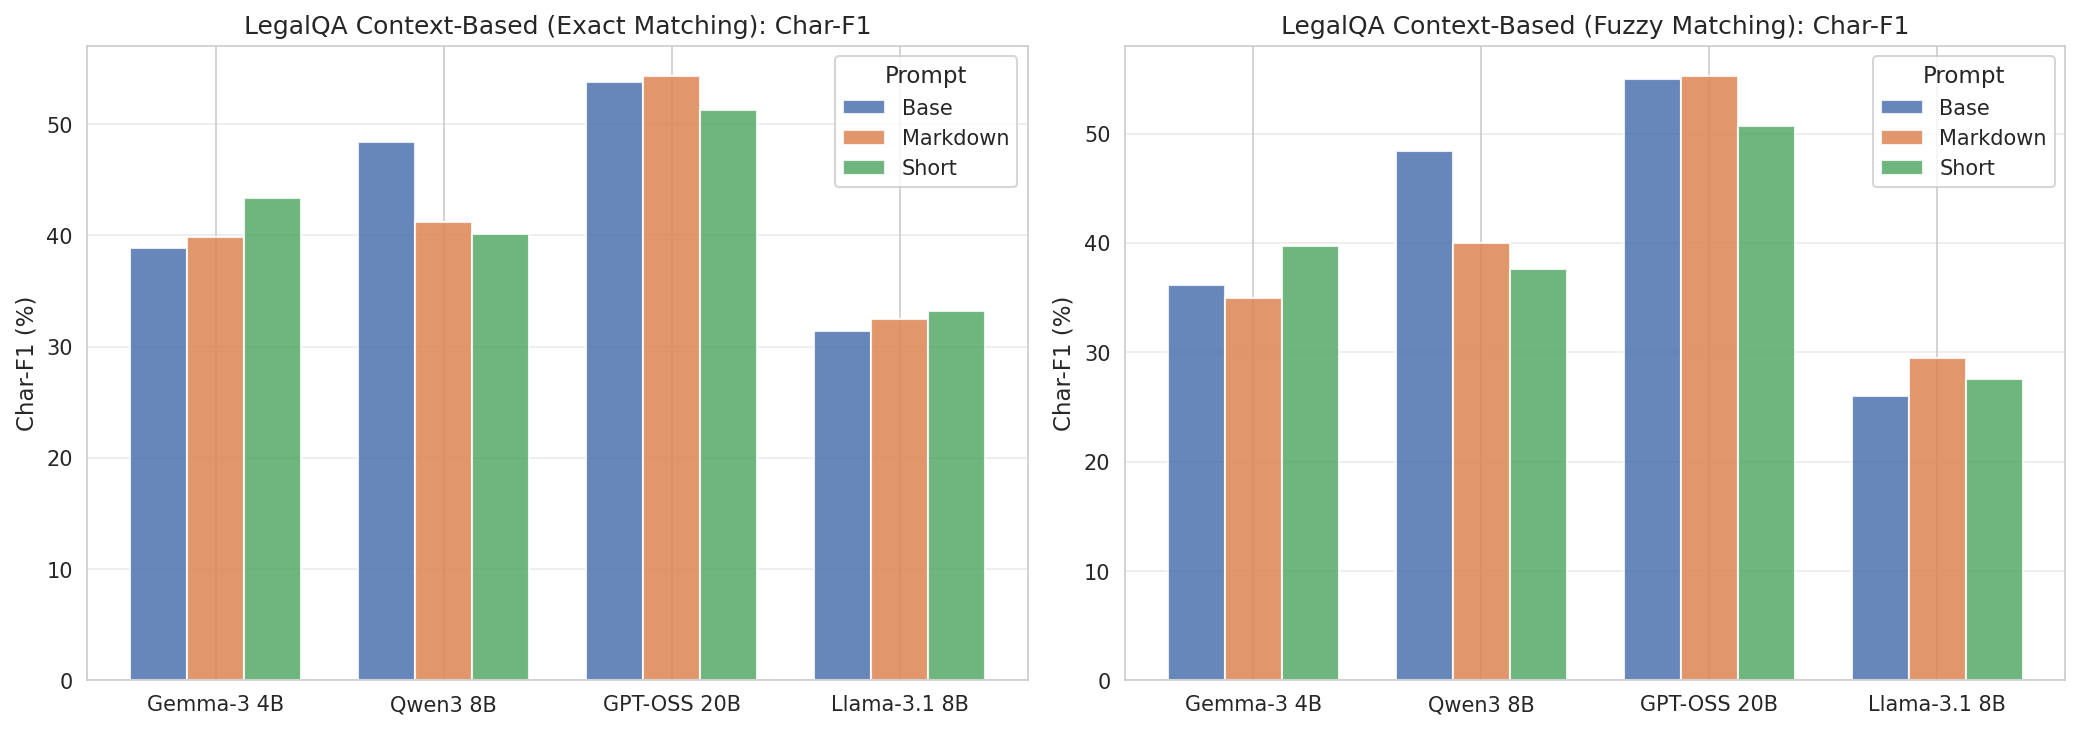

In [29]:
lq_models_ctx = [m for m in ['Gemma-3 4B', 'Qwen3 8B', 'GPT-OSS 20B', 'Llama-3.1 8B']
                 if m in lq_ctx_exact['model_short'].values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, label) in zip(axes, [(lq_ctx_exact, 'Exact'), (lq_ctx_fuzzy, 'Fuzzy')]):
    prompts_lq = sorted(df['prompt_short'].dropna().unique()) if 'prompt_short' in df.columns else ['Base']
    x = np.arange(len(lq_models_ctx))
    width = 0.25
    for i, prompt in enumerate(prompts_lq[:3]):
        sub = df[df['prompt_short'] == prompt] if 'prompt_short' in df.columns else df
        vals = [sub[sub['model_short'] == m]['main_f1_pct'].mean() if len(sub[sub['model_short'] == m]) > 0 else np.nan
                for m in lq_models_ctx]
        ax.bar(x + i * width, vals, width, label=prompt,
               color=list(PROMPT_COLORS.values())[i], alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(lq_models_ctx)
    ax.set_ylabel('Char-F1 (%)')
    ax.set_title(f'LegalQA Context-Based ({label} Matching): Char-F1', fontsize=12)
    ax.legend(title='Prompt')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, 'legalqa_ctx_char_f1_by_prompt')


Saved: legalqa_cg_wrong_text_rate.png


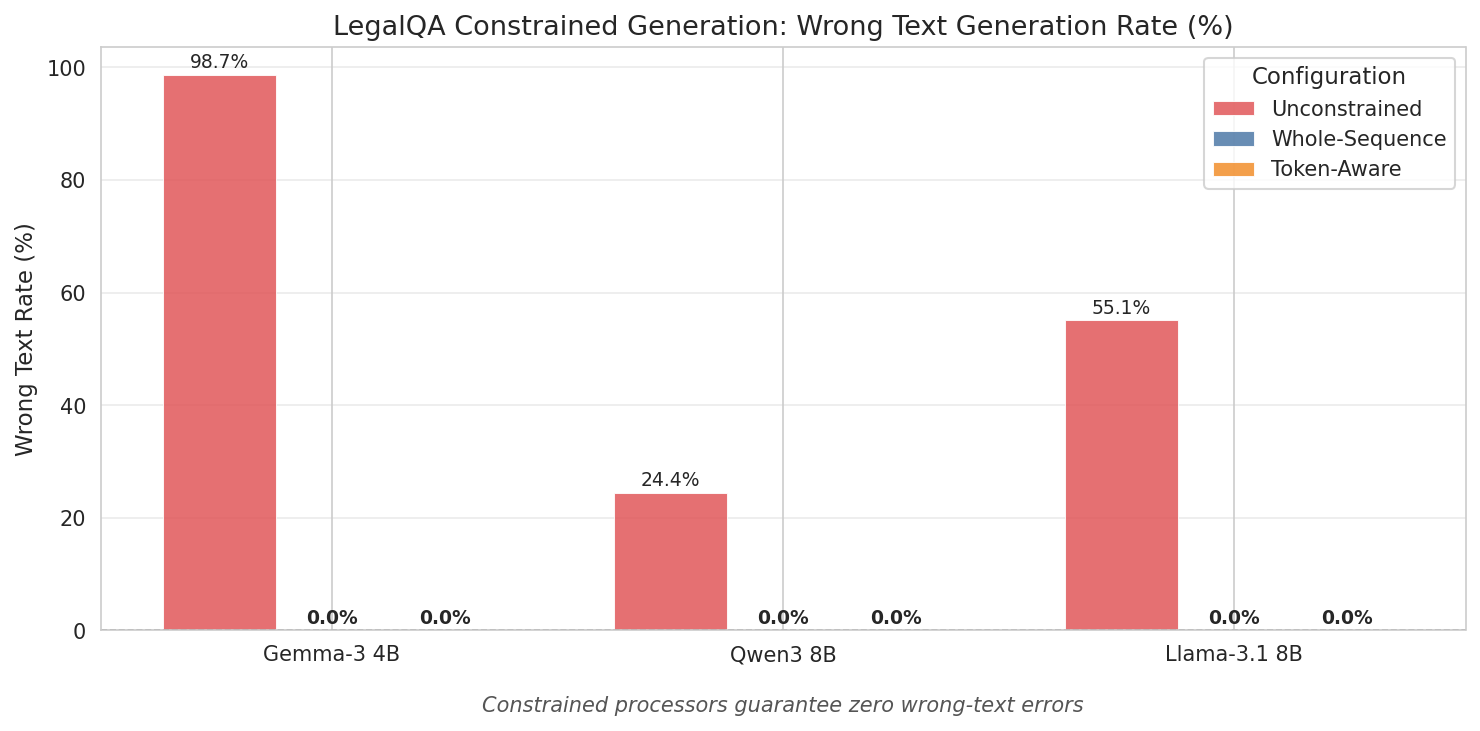

In [30]:
make_wrong_text_plot(
    lq_cg, lq_cg_models,
    'LegalQA Constrained Generation: Wrong Text Generation Rate (%)',
    'legalqa_cg_wrong_text_rate', col='wrong_text_rate_pct'
)


Saved: legalqa_cg_char_f1_comparison.png


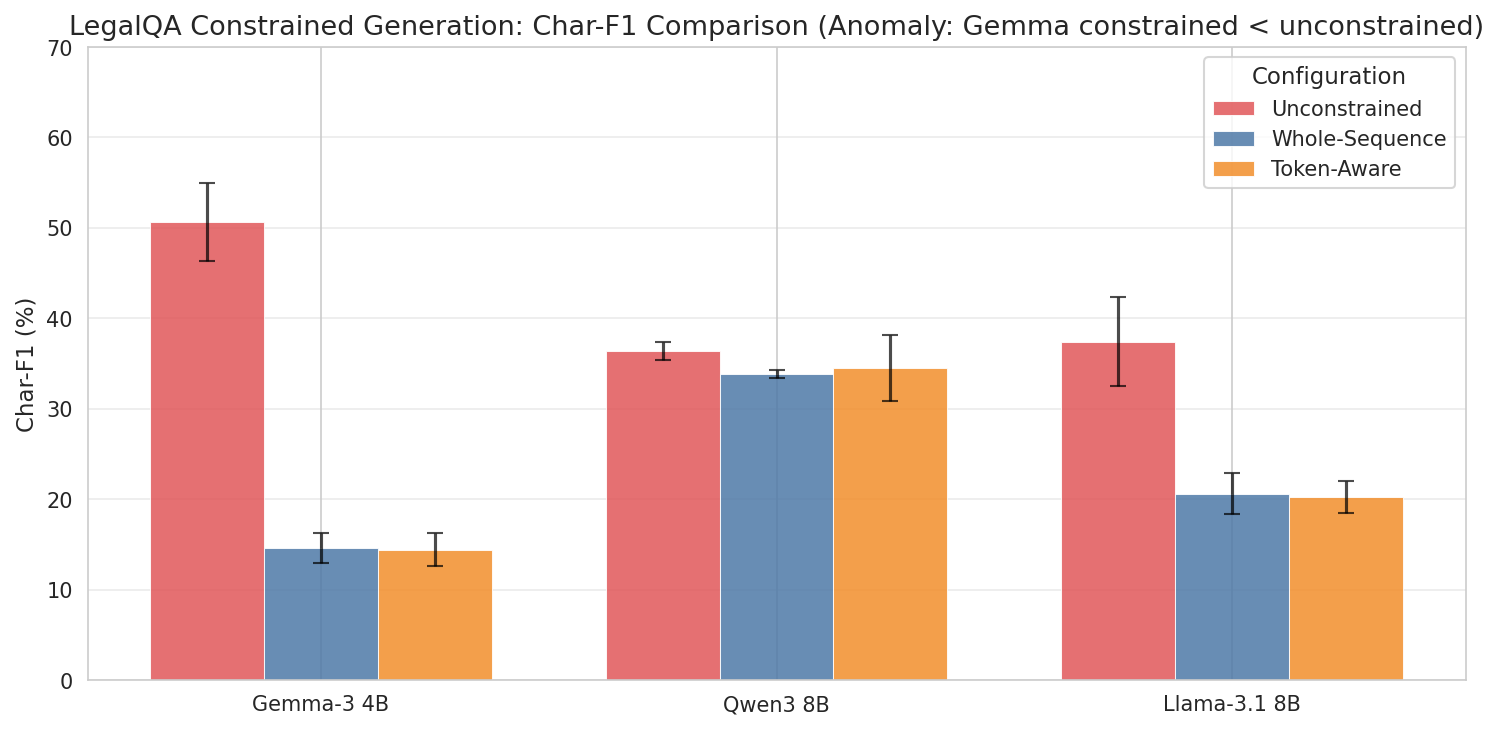

In [31]:
make_f1_comparison_plot(
    lq_cg, lq_cg_models,
    'Char-F1 (%)',
    'LegalQA Constrained Generation: Char-F1 Comparison (Anomaly: Gemma constrained < unconstrained)',
    'legalqa_cg_char_f1_comparison', ylim=70
)


## 7. Cross-Dataset Summary

Summary heatmaps showing the best F1 per (model × dataset) combination for each approach.


Saved: summary_heatmaps.png


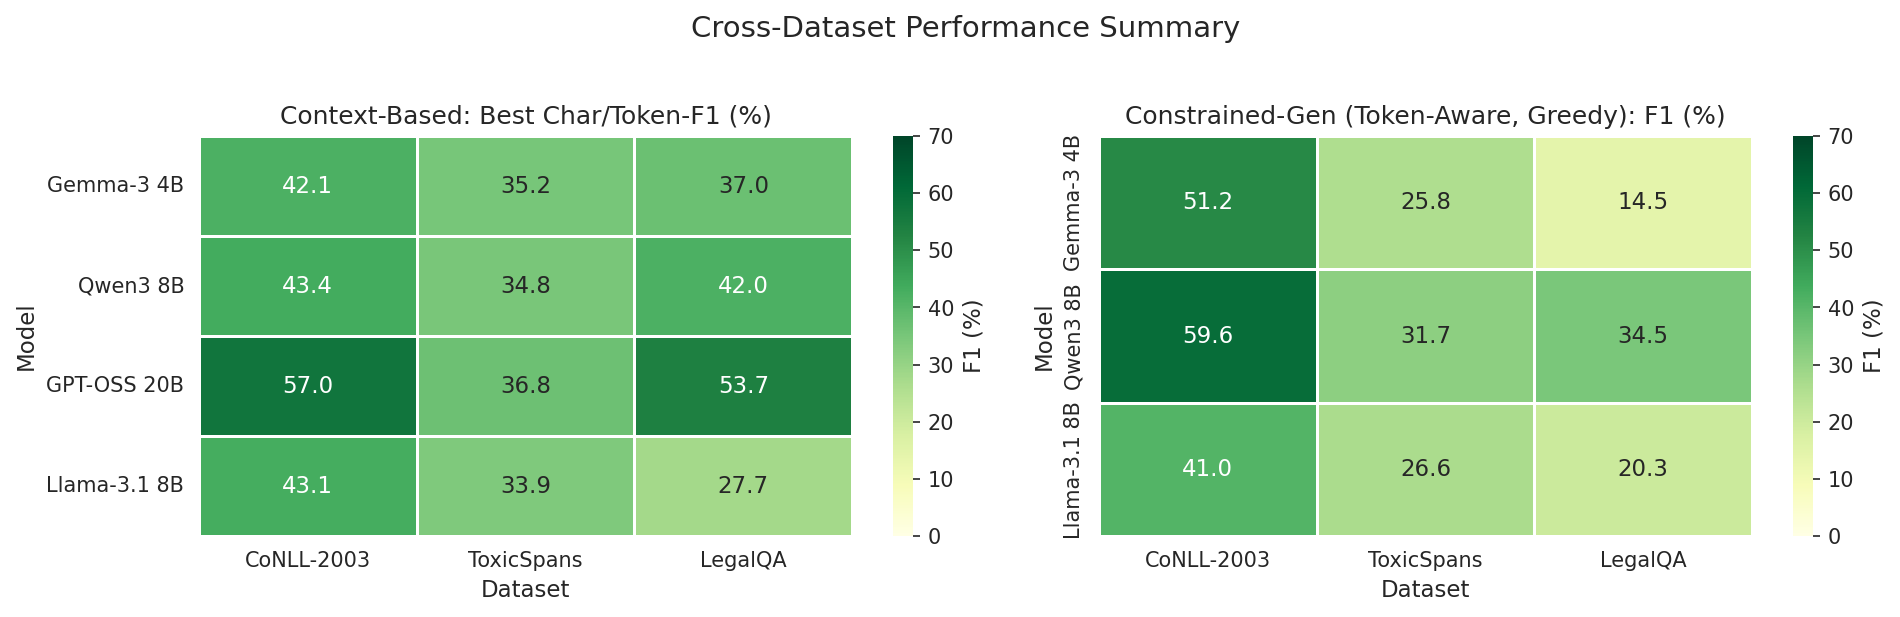

In [32]:
datasets = {
    'CoNLL-2003': (ctx_fuzzy, cg),
    'ToxicSpans': (ts_ctx_fuzzy, ts_cg),
    'LegalQA': (lq_ctx_fuzzy, lq_cg),
}
all_models_ctx = ['Gemma-3 4B', 'Qwen3 8B', 'GPT-OSS 20B', 'Llama-3.1 8B']
all_models_cg = ['Gemma-3 4B', 'Qwen3 8B', 'Llama-3.1 8B']

def build_heatmap_matrix(models, ds_dict, approach):
    mat = []
    for model in models:
        row = []
        for ds_name, (ctx_df, cg_df) in ds_dict.items():
            if approach == 'context':
                sub = ctx_df[ctx_df['model_short'] == model]
                val = sub['main_f1_pct'].mean() if len(sub) > 0 else np.nan
            else:
                df_ta = cg_df[(cg_df['config'] == 'Token-Aware') & (cg_df['model_short'] == model)]
                if 'do_sample' in df_ta.columns:
                    df_ta = df_ta[df_ta['do_sample'].astype(str).str.lower().isin(['false', '0'])]
                val = df_ta['main_f1_pct'].mean() if len(df_ta) > 0 else np.nan
            row.append(val)
        mat.append(row)
    return pd.DataFrame(mat, index=models, columns=list(ds_dict.keys()))

mat_ctx = build_heatmap_matrix(all_models_ctx, datasets, 'context')
mat_cg = build_heatmap_matrix(all_models_cg, datasets, 'constrained')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (mat, title) in zip(axes, [
    (mat_ctx, 'Context-Based: Best Char/Token-F1 (%)'),
    (mat_cg, 'Constrained-Gen (Token-Aware, Greedy): F1 (%)'),
]):
    sns.heatmap(mat.astype(float), ax=ax, annot=True, fmt='.1f',
                cmap='YlGn', linewidths=0.5, linecolor='white',
                vmin=0, vmax=70, cbar_kws={'label': 'F1 (%)'})
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Model')
    ax.set_xlabel('Dataset')

plt.suptitle('Cross-Dataset Performance Summary', fontsize=14, y=1.02)
plt.tight_layout()
save_fig(fig, 'summary_heatmaps')


Saved: summary_wrong_text_all_datasets.png


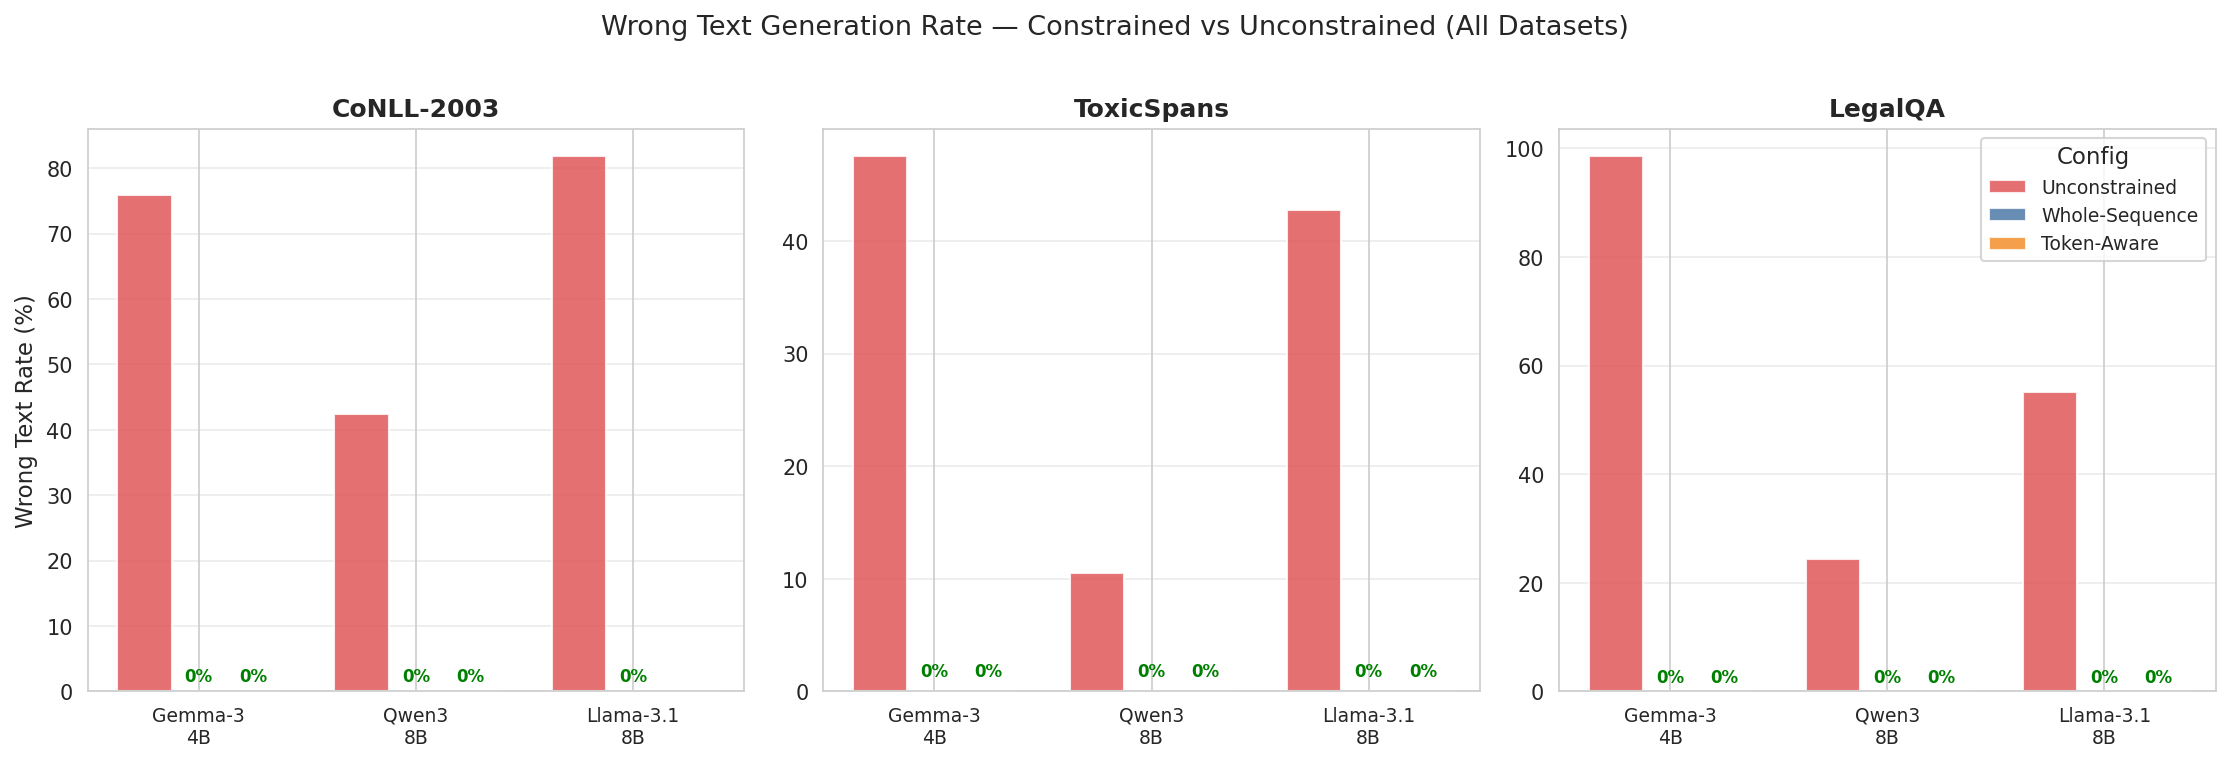

In [33]:
dataset_labels = ['CoNLL-2003', 'ToxicSpans', 'LegalQA']
cg_dfs = [cg, ts_cg, lq_cg]
all_cg_models = ['Gemma-3 4B', 'Qwen3 8B', 'Llama-3.1 8B']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (ds_label, df) in zip(axes, zip(dataset_labels, cg_dfs)):
    df_g = df
    if 'do_sample' in df.columns:
        df_g = df[df['do_sample'].astype(str).str.lower().isin(['false', '0'])]
    configs = ['Unconstrained', 'Whole-Sequence', 'Token-Aware']
    models_here = [m for m in all_cg_models if m in df_g['model_short'].values]
    x = np.arange(len(models_here))
    width = 0.25
    for i, cfg in enumerate(configs):
        vals = []
        for model in models_here:
            sub = df_g[(df_g['model_short'] == model) & (df_g['config'] == cfg)]
            vals.append(sub['wrong_text_rate_pct'].mean() if (
                'wrong_text_rate_pct' in sub.columns and len(sub) > 0) else np.nan)
        bars = ax.bar(x + i * width, vals, width, label=cfg,
                      color=PROC_COLORS[cfg], alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            if not np.isnan(val) and val == 0:
                ax.text(bar.get_x() + bar.get_width() / 2, 1,
                        '0%', ha='center', va='bottom', fontsize=8, color='green', fontweight='bold')

    ax.set_xticks(x + width)
    ax.set_xticklabels([m.replace(' ', '\n') for m in models_here], fontsize=9)
    ax.set_title(ds_label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Wrong Text Rate (%)' if ax == axes[0] else '')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    if ax == axes[2]:
        ax.legend(title='Config', fontsize=9)

plt.suptitle('Wrong Text Generation Rate — Constrained vs Unconstrained (All Datasets)',
             fontsize=13, y=1.01)
plt.tight_layout()
save_fig(fig, 'summary_wrong_text_all_datasets')


In [34]:
summary_rows = []
for ds_label, ctx_df, cg_df_local in zip(
    dataset_labels,
    [ctx_fuzzy, ts_ctx_fuzzy, lq_ctx_fuzzy],
    [cg, ts_cg, lq_cg]
):
    for model in ['Gemma-3 4B', 'Qwen3 8B', 'GPT-OSS 20B', 'Llama-3.1 8B']:
        ctx_sub = ctx_df[ctx_df['model_short'] == model]
        ctx_f1 = f"{ctx_sub['main_f1_pct'].mean():.1f}%" if len(ctx_sub) > 0 else '—'
        cg_sub = cg_df_local[(cg_df_local['model_short'] == model) & (cg_df_local['config'] == 'Token-Aware')]
        if 'do_sample' in cg_sub.columns:
            cg_sub = cg_sub[cg_sub['do_sample'].astype(str).str.lower().isin(['false', '0'])]
        cg_f1 = f"{cg_sub['main_f1_pct'].mean():.1f}%" if len(cg_sub) > 0 else '—'
        summary_rows.append({
            'Dataset': ds_label, 'Model': model,
            'Context-Based F1': ctx_f1, 'Constrained-Gen F1 (Token-Aware)': cg_f1
        })

df_final = pd.DataFrame(summary_rows)
df_final


,Dataset,Model,Context-Based F1,Constrained-Gen F1 (Token-Aware)
0,CoNLL-2003,Gemma-3 4B,42.1%,51.2%
1,CoNLL-2003,Qwen3 8B,43.4%,59.6%
2,CoNLL-2003,GPT-OSS 20B,57.0%,—
3,CoNLL-2003,Llama-3.1 8B,43.1%,41.0%
4,ToxicSpans,Gemma-3 4B,35.2%,25.8%
5,ToxicSpans,Qwen3 8B,34.8%,31.7%
6,ToxicSpans,GPT-OSS 20B,36.8%,—
7,ToxicSpans,Llama-3.1 8B,33.9%,26.6%
8,LegalQA,Gemma-3 4B,37.0%,14.5%
9,LegalQA,Qwen3 8B,42.0%,34.5%
